# Intro

Models will be trained and tuned in this notebook. Data preprocessing will be based on the results of the EDA performed in another notebook.

The main metric is Recall@5% FPR, i.e. the share of correctly identified fraudulent applications among all fraudulent applications, provided that false positive predictions do not exceed 5% of all applications. Thus, this metric takes into account the business interests of the company, since a large share of false positive predictions contributes to the deterioration of user experience and customer churn.

The goal of the work is to obtain the model, showing the best results in cross-validation.
To achieve the goal, the following tasks are set:
- train a simple baseline-model, make quality measurements
- train more complex models
- conduct Time Series cross-validation based on the value of the Month column
- select 2 best models
- use a statistical test to select the best model

# Imports

To perform calculations on kaggle, the parameter kaggle=True

In [1]:
kaggle = False

In [2]:
if kaggle:
    !pip uninstall category-encoders -y
    !pip install scikit-learn==1.6.1
    !pip install xgboost==3.0.1
    !pip install imbalanced-learn-0.13.0
    !pip install shap==0.48.0
    !pip install seaborn==0.13.2

    
    import kagglehub
    path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")

else:
    from pathlib import Path
    PROJECT_ROOT = Path.cwd().parent

In [3]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from scipy.stats import t, ttest_rel
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, \
    make_scorer, check_scoring, brier_score_loss, log_loss
from sklearn.model_selection import BaseCrossValidator, TimeSeriesSplit, cross_validate, cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier
try:
    from imblearn.under_sampling import NearMiss
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError:
    from imblearn.under_sampling import NearMiss
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

## Train-Test Split
Months 6, 7 go to the test part. The division is 80/20.

In [4]:
if kaggle:
    df = pd.read_csv('/kaggle/input/bank-account-fraud-dataset-neurips-2022/Base.csv')
else:
    df = pd.read_csv(PROJECT_ROOT / "data" / "Bank Account Fraud Dataset" / "account_fraud.csv")

X_train, y_train = df[~df.month.isin([6, 7])].drop(['fraud_bool'], axis=1), df[~df.month.isin([6, 7])]['fraud_bool']
X_test, y_test = df[df.month.isin([6, 7])].drop(['fraud_bool'], axis=1), df[df.month.isin([6, 7])]['fraud_bool']

del df

# Declaring classes to handle data and functions

- TimeSeriesMonthSplit - Custom class for splits for cross validation by the value of the Month column;
- NoneHandler - Custom class for handling missing values
- DataHandler - Custom class for dataset processing, like in the EDA-notebook
- DataPreprocessor - Custom class for feature selection, adding features based on functions and PCA, applying ColumnTransformer (StandardScaler, OHE, MTE)
- IsoForest - Custom class for adding a feature obtained using IsolationForest

In [5]:
if not kaggle:
    from DataTransformer import TimeSeriesMonthSplit, NoneHandler, DataHandler, DataPreprocessor, IsoForest

else:    
    class TimeSeriesMonthSplit(BaseCrossValidator):
        """
        Custom class for splits for cross validation by the value of the Month column
        """
    
        def __init__(self, ):
            pass
    
        def get_n_splits(self, X, y=None, groups=None):
            unique_months = sorted(X['month'].unique())
            return len(unique_months) - 1
    
        def split(self, X, y=None, groups=None):
            cv = []
    
            unique_months = sorted(X['month'].unique())
            for i in range(len(unique_months) - 1):
                train_months = unique_months[:i + 1]
                val_month = unique_months[i + 1]
    
                cv.append([X[X['month'].isin(train_months)].index, X[X['month'] == val_month].index])
    
            return cv
    
    
    class NoneHandler(BaseEstimator, TransformerMixin):
        """
        Custom class for handling missing values
        """
    
        def __init__(self):
            self.handler_params = {'prev_address_months_count': -1,
                                   'current_address_months_count': 0,
                                   'bank_months_count': 0,
                                   'device_distinct_emails_8w': 0,
                                   'velocity_6h': None,  # distribution covers -1
                                   'credit_risk_score': None,  # distribution covers -1
                                   }
            self.num_features = ['session_length_in_minutes', 'bank_branch_count_8w', 'velocity_24h',
                                 'current_address_months_count',
                                 'credit_risk_score', 'velocity_6h', 'name_email_similarity', 'days_since_request',
                                 'prev_address_months_count', 'intended_balcon_amount', 'bank_months_count',
                                 'device_fraud_count',
                                 'date_of_birth_distinct_emails_4w', 'velocity_4w', 'zip_count_4w']
    
        def fit(self, X, y=None):
            self._is_fitted = True
            return self
    
        def transform(self, X, y=None):
            check_is_fitted(self)
            X = X.copy()
    
            for column in X.columns:
                if np.sum(X[column] == -1):
                    if column in self.handler_params:
                        if self.handler_params.get(column, None) is None:
                            continue
                        else:
                            X.loc[X[column] == -1, column] = self.handler_params[column]
                    else:
                        if column in self.num_features:
                            X.loc[X[column] == -1, column] = X[column].median()
                        else:
                            X.loc[X[column] == -1, column] = X[column].mode().item()
    
                if X[column].isna().any():
                    if column in self.handler_params:
                        if self.handler_params.get(column, None) is None:
                            continue
                        else:
                            X.loc[X[column].isna(), column] = self.handler_params[column]
                    else:
                        if column in self.num_features:
                            X.loc[X[column].isna(), column] = X[column].median()
                        else:
                            X.loc[X[column].isna(), column] = X[column].mode().item()
    
            if 'intended_balcon_amount' in X.columns:
                X.loc[X.intended_balcon_amount < 0, 'intended_balcon_amount'] = -1
    
            return X
    
        def __sklearn_is_fitted__(self):
            """
            Check fitted status and return a Boolean value.
            """
            return hasattr(self, "_is_fitted") and self._is_fitted
    
    
    class DataHandler(BaseEstimator, TransformerMixin):
        """
        Custom class for dataset processing, like in the EDA-notebook
        """
    
        def __init__(self):
            pass
    
        def fit(self, X, y=None):
            self._is_fitted = True
            return self
    
        def transform(self, X, y=None):
            check_is_fitted(self)
            X = X.copy()
    
            if 'device_distinct_emails' in X.columns:
                X.loc[X.device_distinct_emails_8w != 1, 'device_distinct_emails_8w'] = 2
    
            if 'device_os' in X.columns:
                X.loc[X.device_os.isin(['x11']), 'device_os'] = 'other'
    
            if 'housing_status' in X.columns:
                X.loc[X.housing_status.isin(['BD', 'BF', 'BG']), 'housing_status'] = 'other'
    
            if 'employment_status' in X.columns:
                X.loc[X.employment_status.isin(['CD', 'CE', 'CF', 'CG']), 'employment_status'] = 'other'
    
            if 'name_email_similarity' in X.columns and 'has_other_cards' in X.columns:
                X['EDA'] = np.zeros(len(X))
                X.loc[(X.name_email_similarity < 0.35) & (X.has_other_cards == 1), 'EDA'] = 1
    
            if 'proposed_credit_limit' in X.columns:
                X.loc[X.proposed_credit_limit < 1000, 'proposed_credit_limit'] = 0
                X.loc[(X.proposed_credit_limit >= 1000) & (X.proposed_credit_limit < 1900), 'proposed_credit_limit'] = 1
                X.loc[X.proposed_credit_limit >= 1900, 'proposed_credit_limit'] = 2
    
            return X
    
        def __sklearn_is_fitted__(self):
            """
            Check fitted status and return a Boolean value.
            """
            return hasattr(self, "_is_fitted") and self._is_fitted
    
    
    class DataPreprocessor(BaseEstimator, TransformerMixin):
        """
        Custom class for feature selection, adding features based on functions and PCA, 
        applying ColumnTransformer (StandardScaler, OHE, MTE).
        """
    
        def __init__(self,
                     cat_features=None,
                     num_features=None,
                     pca_features=None,
                     pca_n_components=None,
                     custom_functions=None,
                     num_ohe_mte_threshold=5,
                     ):
            self.cat_features = cat_features
            self.num_features = num_features
            self.pca_features = pca_features
            self.pca_n_components = pca_n_components
            self.custom_functions = custom_functions
            self.num_ohe_mte_threshold = num_ohe_mte_threshold
    
        def fit(self, X, y=None):
            X = X.copy()
    
            self._cat_features = self.cat_features.copy() if self.cat_features else []
            self._num_features = self.num_features.copy() if self.num_features else []
    
            self.similarity_storage = {}
            self.excess_ratio_storage = {}
    
            if self.pca_features is not None:
                # 1. Add PCA
                self._fit_pca(X)
    
                # 2. Add PCA
                self.pca_columns = [f'pca_feature_{i}' for i in range(self.pca_n_components)]
                self._num_features += self.pca_columns
    
                # Modify df
                pca_values = self.pca.transform(X[self.pca_features])
                for i, col in enumerate(self.pca_columns):
                    X[col] = pca_values[:, i]
    
            # 3. Process custom features
            if self.custom_functions is not None:
                self.generated_columns = []
                for func, cols in self.custom_functions:
                    if func == 'similarity':
                        main_feature, base_features = cols
                        X, new_feature_name = self._fit_similarity(main_feature, base_features, X)
                        self._cat_features.append(new_feature_name)
                        self.generated_columns.append((new_feature_name, func, (main_feature, base_features)))
                    elif func == 'excess_ratio':
                        main_feature, base_features = cols
                        X, new_feature_name = self._fit_excess_ratio(
                            main_feature=main_feature,
                            base_features=base_features,
                            X=X)
                        self._cat_features.append(new_feature_name)
                        self.generated_columns.append((new_feature_name, func, (main_feature, base_features)))
    
                    else:
                        if func == 'not_round':
                            func = self.not_round
                        for col in cols:
                            new_col = f"{col}_{func.__name__}"
                            X[new_col] = func(X[col])
                            self.generated_columns.append((new_col, func, col))
                            if np.issubdtype(X[new_col].dtype, np.number):
                                self._num_features.append(new_col)
                            else:
                                self._cat_features.append(new_col)
    
            # 4. Fit ColumnTransformer
            self._fit_transformer(X, y)
    
            # 5. List of all final features
            ohe_feature_names = self._get_ohe_feature_names()
            self.transformed_feature_names_ = (
                    self._num_features + ohe_feature_names + self.mte_features
            )
    
            return self
    
        def transform(self, X, y=None):
            X = X.copy()
    
            # Shortcut-mask
            self.shortcut_mask = X['device_fraud_count'] > 0
    
            if self.pca_features is not None:
                # PCA
                pca_values = self.pca.transform(X[self.pca_features])
                for i, col in enumerate(self.pca_columns):
                    X[col] = pca_values[:, i]
    
            # Custom features
            if self.custom_functions is not None:
                for new_col, func, base_col in self.generated_columns:
                    if func == 'similarity':
                        main_feature, base_features = base_col
                        X = self._similarity(new_col, main_feature, base_features, X)
                    elif func == 'excess_ratio':
                        main_feature, base_features = base_col
                        X = self._excess_ratio(
                            new_feature_name=new_col,
                            main_feature=main_feature,
                            base_features=base_features,
                            X=X
                        )
    
                    else:
                        if func == 'not_round':
                            func = self.not_round
                        X[new_col] = func(X[base_col])
    
            # Remove unnecessary features
            keep_cols = set(self._num_features + self._cat_features)
            X = X[[col for col in X.columns if col in keep_cols]]
    
            # Transform
            transformed = self.column_transformer.transform(X)
    
            # Wrap in DataFrame
            return pd.DataFrame(transformed, columns=self.transformed_feature_names_, index=X.index)
    
        def predict(self, X, model):
            X_processed = self.transform(X)
    
            preds = model.predict(X_processed)
    
            # shortcut
            preds = np.where(self.shortcut_mask.values, 1, preds)
    
            return preds
    
        def _fit_pca(self, X):
            self.pca = PCA(n_components=self.pca_n_components)
            self.pca.fit(X[self.pca_features])
    
        def _fit_transformer(self, X, y):
            self.ohe_features = [x for x in self._cat_features if X[x].nunique() < self.num_ohe_mte_threshold]
            self.mte_features = [x for x in self._cat_features if X[x].nunique() >= self.num_ohe_mte_threshold]
    
            num_transformer = Pipeline([
                ('scaler', StandardScaler())
            ])
    
            most_frequent = [X[col].value_counts().idxmax() for col in self.ohe_features]
            ohe_transformer = Pipeline([
                ('ohe', OneHotEncoder(drop=most_frequent, sparse_output=False, handle_unknown='warn'))
            ])
    
            mte_transformer = Pipeline([
                ('mte', TargetEncoder(cv=5, shuffle=True, random_state=42))
            ])
    
            self.column_transformer = ColumnTransformer(transformers=[
                ('num', num_transformer, self._num_features),
                ('ohe', ohe_transformer, self.ohe_features),
                ('mte', mte_transformer, self.mte_features)
            ], remainder='drop', n_jobs=-1)
    
            self.column_transformer.fit(X, y)
    
        def _get_ohe_feature_names(self):
            ohe = self.column_transformer.named_transformers_['ohe'].named_steps['ohe']
            feature_names = ohe.get_feature_names_out(self.ohe_features)
            return list(feature_names)
    
        def _fit_similarity(self, main_feature: str, base_features: list, X: pd.DataFrame):
            counts = (
                X[[*base_features, main_feature]].groupby([*base_features, main_feature], observed=True)
                .size()
                .reset_index(name='count')
            )
    
            new_feature_name = f"{main_feature}_similarity_rank_by_{'_'.join(base_features)}"
    
            counts[new_feature_name] = -1 * (
                counts
                .sort_values([*base_features, 'count'], ascending=[True, True, False])
                .groupby(base_features, observed=True)
                .cumcount()
            )
    
            counts.loc[counts[new_feature_name] <= -3, new_feature_name] = -3
            max_rank = counts[new_feature_name].min()
            self.similarity_storage[new_feature_name] = (counts, max_rank)
    
            X = self._similarity(new_feature_name, main_feature, base_features, X)
            return X, new_feature_name
    
        def _similarity(self, new_feature_name: str, main_feature: str, base_features: list, X: pd.DataFrame):
    
            counts, max_rank = self.similarity_storage[new_feature_name]
    
            X = X.merge(
                counts[[*base_features, main_feature, new_feature_name]],
                on=[*base_features, main_feature],
                how='left'
            )
            X[new_feature_name] = X[new_feature_name].fillna(max_rank)
    
            return X
    
        def _fit_excess_ratio(self, main_feature: str, base_features: list, X: pd.DataFrame):
            counts = (
                X[[*base_features, main_feature]]
                .groupby([*base_features], observed=True)
                .median()
                .rename(columns={main_feature: f'{main_feature}_median'})
                .reset_index()
            )
            new_feature_name = f"{main_feature}_excess_ratio_by_{'_'.join(base_features)}"
    
            self.excess_ratio_storage[new_feature_name] = counts
    
            X = self._excess_ratio(new_feature_name, main_feature, base_features, X)
            return X, new_feature_name
    
        def _excess_ratio(self, new_feature_name: str, main_feature: str, base_features: list, X: pd.DataFrame):
    
            counts = self.excess_ratio_storage[new_feature_name]
    
            X = X.merge(
                counts[[*base_features, f'{main_feature}_median']],
                on=base_features,
                how='left'
            )
    
            X[new_feature_name] = X[main_feature] / X[f'{main_feature}_median']
            X = X.drop(f'{main_feature}_median', axis=1)
    
            return X
    
        def not_round(self, ser):
            def _nr(num):
                if (num >= 1000 and num % 500 == 0) or (num < 1000 and num % 100 == 0):
                    return False
                else:
                    return True
    
            return ser.apply(_nr)
    
    
    class IsoForest(BaseEstimator, TransformerMixin):
        """
        Class to add IsolationForest mark to the dataset
        """
    
        def __init__(self, n_estimators=200, bootstrap=True, contamination='by_sample', column_name=None):
            self.n_estimators = n_estimators
            self.bootstrap = bootstrap
            self.contamination = contamination
            self.column_name = column_name
    
        def fit(self, X, y=None):
    
            if self.contamination == 'by_sample':
                con = np.sum(y) / len(y)
            else:
                con = self.contamination
    
            self.iso = IsolationForest(
                n_estimators=self.n_estimators,
                bootstrap=self.bootstrap,
                contamination=con,
                random_state=42,
                n_jobs=-1,
            )
    
            self.iso.fit(X)
            self._is_fitted = True
            return self
    
        def transform(self, X, y=None):
            check_is_fitted(self)
            X = X.copy()
    
            if self.column_name is None:
                col_name = 'IsolationForestMark'
            else:
                col_name = self.column_name
    
            X[col_name] = np.where(self.iso.predict(X) == -1, 1, 0)
            return X
    
        def __sklearn_is_fitted__(self):
            """
            Check fitted status and return a Boolean value.
            """
            return hasattr(self, "_is_fitted") and self._is_fitted

Declare the metric function

In [6]:
def recall_at_fpr_threshold(y_true, y_scores, fpr_threshold=0.05):
    """
    the metric function
    """    
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    valid = np.where(fpr <= fpr_threshold)[0].max()
    return tpr[valid]


recall_a5_fpr = make_scorer(
    recall_at_fpr_threshold,
    greater_is_better=True,
    response_method=['predict_proba', 'decision_function'],
)

Declare the report fucntion 

In [7]:
def model_report(model, X_train, y_train, X_test, y_test):
    """
    the report fucntion
    """

    def make_roc_curve(fpr, tpr, auc, ax, color='orange', title='Test'):
        ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})", color=color)
        ax.plot([0, 1], [0, 1], 'k--')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{title} ROC Curve")
        ax.grid()
        ax.legend()

    if not isinstance(model, Pipeline):
        est = model
    else:
        est = model[-1]
        while isinstance(est, Pipeline):
            est = est[-1]
        
    if 'predict_proba' in dir(est):
        y_score_ = model.predict_proba(X_train)[:,1]
        y_score = model.predict_proba(X_test)[:,1]
        y_pred = (y_score >= 0.5).astype(int)
    
    elif 'decision_function' in dir(est):
        y_score_ = model.decision_function(X_train)
        y_score = model.decision_function(X_test)
        y_pred = (y_score >= 0.0).astype(int)  # 0.0 is similar to 0.5-threshold of logistic regression

    else:
        raise ValueError
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    fpr_, tpr_, thresholds_ = roc_curve(y_train, y_score_)
    auc_ = roc_auc_score(y_train, y_score_)
    make_roc_curve(fpr=fpr_, tpr=tpr_, auc=auc_, ax=axes[0][0], color='blue', title='Train')

    
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    make_roc_curve(fpr=fpr, tpr=tpr, auc=auc, ax=axes[0][1])

    idx = np.where(fpr <= 0.05)[0].max()  # index FPR<=5%
    threshold_5_fpr = thresholds[idx]
    

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_).plot(ax=axes[1][0])
    axes[1][0].set_title('Confusion Matrix')


    cm = confusion_matrix(y_test, (y_score >= threshold_5_fpr).astype(int), labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_).plot(ax=axes[1][1])
    axes[1][1].set_title(f'Confusion Matrix, \n Recall@5% FPR {np.round(tpr[idx], 3)}')

    return fig, axes

I will preprocess all cross-validation splits, save them as one big dataframe and will return indexes of each split. It will speed up significantly cross-validation, but requires more RAM

In [8]:
def preprocess(preprocessor, X_train, y_train, return_transformers=False):
    """
    the function performs preprocessing for cross-validation splits and saves a dataset consisting of cross-validation splits
    """  

    transformers = dict() if return_transformers else None
    _cv = []
    cv = []
    last_idx = 0

    X_parts = []
    y_parts = []

    
    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    t = datetime.datetime.now()
    print('s', t)

    months_sorted = np.sort(X_train['month'].unique())

    for i, month in enumerate(months_sorted[:-1]):
        
        idx = X_train[X_train['month'] <= month].index
        idx_t = X_train[X_train['month'] == months_sorted[i + 1]].index

        _cv.append((idx, idx_t))

        # train sample
        x_train = preprocessor.fit_transform(X_train.loc[idx], y_train.loc[idx])
        y_train_part = y_train.loc[idx]

        if return_transformers:
            transformers[month] = preprocessor

        X_parts.append(pd.DataFrame(x_train).reset_index(drop=True))
        y_parts.append(y_train_part.reset_index(drop=True))

        # validation sample
        x_val = preprocessor.transform(X_train.loc[idx_t])
        y_val_part = y_train.loc[idx_t]

        X_parts.append(pd.DataFrame(x_val).reset_index(drop=True))
        y_parts.append(y_val_part.reset_index(drop=True))

        delta = int((datetime.datetime.now() - t).total_seconds())
        t = datetime.datetime.now()
        
        print(f"Month {month} ended at {t}, total {delta} seconds")

    X_transformed = pd.concat(X_parts, axis=0, ignore_index=True)
    y_transformed = pd.concat(y_parts, axis=0, ignore_index=True)

    for i in _cv:
        cv.append((
            pd.RangeIndex(start=last_idx, stop=last_idx+len(i[0])),
            pd.RangeIndex(start=last_idx+len(i[0]), stop=last_idx+len(i[0])+len(i[1]))
        ))
        last_idx += len(i[0])+len(i[1])

    if X_transformed.isna().any().any():
        print('\nThere are some Na values!!!\n')
        print('Columns with Na:')
        for col in X_transformed.columns:
            if X_transformed[col].isna().any():
                print(col)
    print()
    if return_transformers:
        return X_transformed, y_transformed, cv, transformers

    else:
        return X_transformed, y_transformed, cv        


# Baseline

To start, I will use simple linear models like Logistic Regression and LinearSVC.

## Data preprocessing for baseline

In [9]:
%%time

dp_base = DataPreprocessor(
    cat_features=[
        'email_is_free', 'has_other_cards',  'keep_alive_session', 'phone_home_valid',  'phone_mobile_valid', 'device_os',
        'employment_status', 'customer_age', 'payment_type',  'housing_status', 'foreign_request',  'income', 'device_distinct_emails_8w',
        'proposed_credit_limit',
    ],
    num_features=[
        'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 
        'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'session_length_in_minutes', 'days_since_request', 
        'velocity_6h', 'velocity_24h', 'velocity_4w',
    ],
    num_ohe_mte_threshold=5
)


preprocessor_base = Pipeline([
    ('none_handler', NoneHandler()),
    ('data_preprocessor', dp_base),
])

X_base, y_base, cv_base = preprocess(preprocessor_base, X_train, y_train)

s 2025-08-14 16:11:03.951669
Month 0 ended at 2025-08-14 16:11:08.534704, total 4 seconds
Month 1 ended at 2025-08-14 16:11:11.006261, total 2 seconds
Month 2 ended at 2025-08-14 16:11:14.350036, total 3 seconds
Month 3 ended at 2025-08-14 16:11:18.570989, total 4 seconds
Month 4 ended at 2025-08-14 16:11:23.704146, total 5 seconds

CPU times: total: 9.23 s
Wall time: 20.1 s


## Logistic Regression

The following hyperparameters were chosen for logistic regression:
- class_weight='balanced' - to hadle the imbalanced class
- penalty='elasticnet' - to cross-validate with l1 and l2 penalty
- solver='saga' - because it supports elasticnet penalty
- max_iter=200 - as a balance between learning speed and quality

GridSearchCV will be performed on the parameters C (regularization strength) and l1_ratio (Elastic-Net mixing parameter - the predominance of regularization l1 or l2)

In [10]:
%%time

lr = LogisticRegression(penalty='elasticnet', class_weight='balanced', random_state=42, solver='saga', n_jobs=-1, max_iter=200)

Cs = [0.01, 1.0, 10.0]
l_one = [0.3, 0.7]

gs_lr = GridSearchCV(
    lr, 
    param_grid={'C': Cs, 'l1_ratio': l_one},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR',
    n_jobs=-1, 
    cv=cv_base,
    return_train_score=True
)

gs_lr.fit(X_base, y_base)

CPU times: total: 6min 48s
Wall time: 13min 5s


C:\Users\Aleks\PycharmProjects\FraudDetection\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=[(RangeIndex(start=0, stop=132440, step=1),
                  RangeIndex(start=132440, stop=260060, step=1)),
                 (RangeIndex(start=260060, stop=520120, step=1),
                  RangeIndex(start=520120, stop=657099, step=1)),
                 (RangeIndex(start=657099, stop=1054138, step=1),
                  RangeIndex(start=1054138, stop=1205074, step=1)),
                 (RangeIndex(start=1205074, stop=1753049, step=1),
                  RangeIndex(start=1...
             estimator=LogisticRegression(class_weight='balanced', max_iter=200,
                                          n_jobs=-1, penalty='elasticnet',
                                          random_state=42, solver='saga'),
             n_jobs=-1,
             param_grid={'C': [0.01, 1.0, 10.0], 'l1_ratio': [0.3, 0.7]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, that is, I will choose more stable models.

In [11]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_lr.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
4,"{'C': 10.0, 'l1_ratio': 0.3}",0.477928,0.504141,0.012889,0.494474,0.862609,0.878546,0.012451,0.869208
5,"{'C': 10.0, 'l1_ratio': 0.7}",0.476401,0.503387,0.011954,0.494421,0.861941,0.878034,0.012211,0.868875
3,"{'C': 1.0, 'l1_ratio': 0.7}",0.475355,0.501579,0.011585,0.492890,0.860645,0.877033,0.011934,0.868082
2,"{'C': 1.0, 'l1_ratio': 0.3}",0.474524,0.503671,0.015398,0.492122,0.859341,0.876423,0.013332,0.866425
1,"{'C': 0.01, 'l1_ratio': 0.7}",0.393674,0.414295,0.034325,0.388551,0.819563,0.838646,0.020695,0.823125
0,"{'C': 0.01, 'l1_ratio': 0.3}",0.379925,0.397343,0.028507,0.375962,0.812941,0.831705,0.017440,0.818625


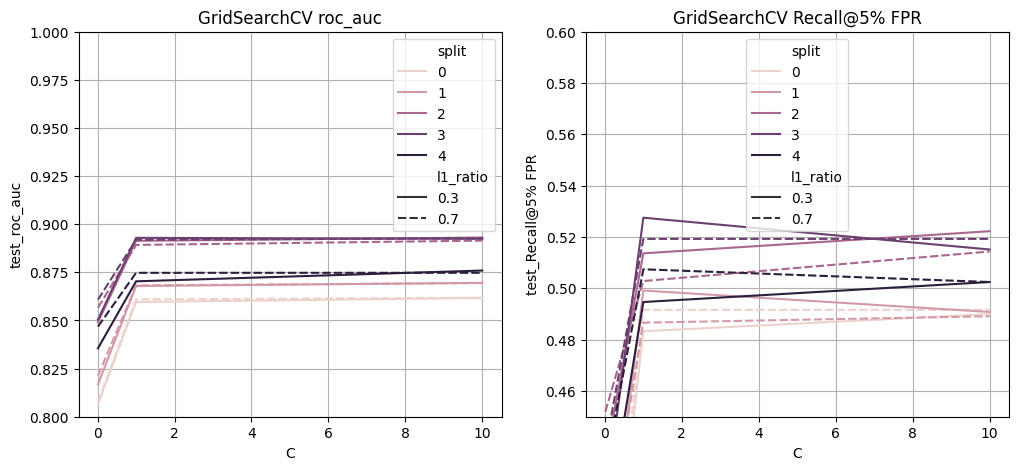

In [12]:
_res = gs_lr.cv_results_
_cv = cv_base

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_C'][i], _res['param_l1_ratio'][i], _res[f'split{j}_test_roc_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['C', 'l1_ratio', 'test_roc_auc', 'test_Recall@5% FPR', 'split'])

lr_base_res, lr_base_res_axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.lineplot(data=_df, x='C', y='test_roc_auc', ax=lr_base_res_axes[0], hue='split', style='l1_ratio')
sns.lineplot(data=_df, x='C', y='test_Recall@5% FPR', ax=lr_base_res_axes[1], hue='split', style='l1_ratio')

lr_base_res_axes[0].set_ylim((0.8, 1))
lr_base_res_axes[1].set_ylim((0.45, 0.6))

lr_base_res_axes[0].grid(True)
lr_base_res_axes[1].grid(True)

lr_base_res_axes[0].set_title('GridSearchCV roc_auc')
lr_base_res_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

Chosen best parameters: l1_ratio=0.7, C=10.

C:\Users\Aleks\PycharmProjects\FraudDetection\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


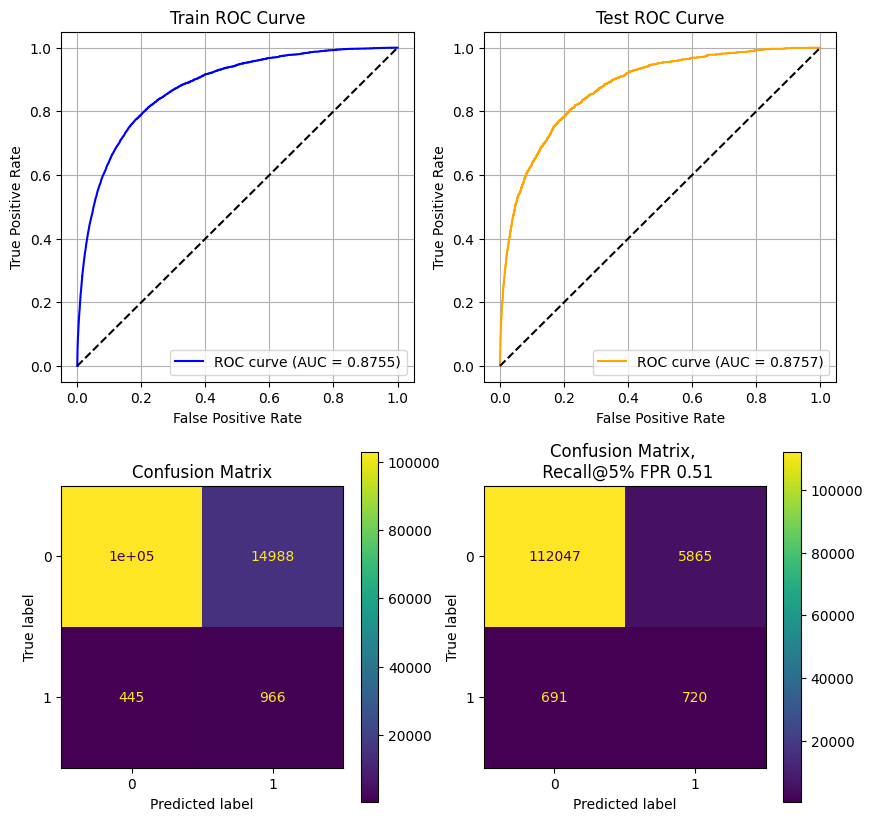

CPU times: total: 1min 36s
Wall time: 1min 41s


In [13]:
%%time

pipe_lr = Pipeline([
    ('preprocessor', dp_base),
    ('model', LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.7, C=10, class_weight='balanced', random_state=42,  n_jobs=-1, max_iter=200)),
])

pipe_lr.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

fig_lr, axes_lr = model_report(
    pipe_lr,
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

## Support Vector Machine Classifier

LiniarSVC has fewer options to tune. Parameter is chosen class_weight='balanced' to hadle the imbalanced class. 

GridSearchCV will be performed on the parameter C (regularization strength).

LinearSVC does not return probabilities - only confidence scores for samples with decision_function.

In [14]:
%%time


svc = LinearSVC(class_weight='balanced', random_state=42)

Cs = [0.01, 0.1, 1.0, 5.0, 7.5, 10.0, 15]

gs_svc = GridSearchCV(
    svc, 
    param_grid={'C': Cs},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR',
    n_jobs=-1, 
    cv=cv_base,
    return_train_score=True
)

gs_svc.fit(X_base, y_base)

CPU times: total: 2min 25s
Wall time: 5min 54s


GridSearchCV(cv=[(RangeIndex(start=0, stop=132440, step=1),
                  RangeIndex(start=132440, stop=260060, step=1)),
                 (RangeIndex(start=260060, stop=520120, step=1),
                  RangeIndex(start=520120, stop=657099, step=1)),
                 (RangeIndex(start=657099, stop=1054138, step=1),
                  RangeIndex(start=1054138, stop=1205074, step=1)),
                 (RangeIndex(start=1205074, stop=1753049, step=1),
                  RangeIndex(start=1...
                 (RangeIndex(start=1880740, stop=2556406, step=1),
                  RangeIndex(start=2556406, stop=2675729, step=1))],
             estimator=LinearSVC(class_weight='balanced', random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1.0, 5.0, 7.5, 10.0, 15]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

In [15]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_svc.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
6,{'C': 15},0.481470,0.508226,0.014983,0.496990,0.864455,0.880039,0.011858,0.871145
3,{'C': 5.0},0.481466,0.507801,0.014469,0.496950,0.864450,0.880029,0.011888,0.871113
1,{'C': 0.1},0.477735,0.507558,0.014378,0.496774,0.861879,0.877943,0.013477,0.867835
2,{'C': 1.0},0.481679,0.507353,0.014249,0.496666,0.864354,0.879932,0.012064,0.870884
4,{'C': 7.5},0.481367,0.507634,0.014724,0.496592,0.864452,0.880034,0.011872,0.871130
5,{'C': 10.0},0.481323,0.507634,0.014724,0.496592,0.864454,0.880036,0.011865,0.871137
0,{'C': 0.01},0.439416,0.465213,0.035103,0.438886,0.841837,0.860207,0.020300,0.844982


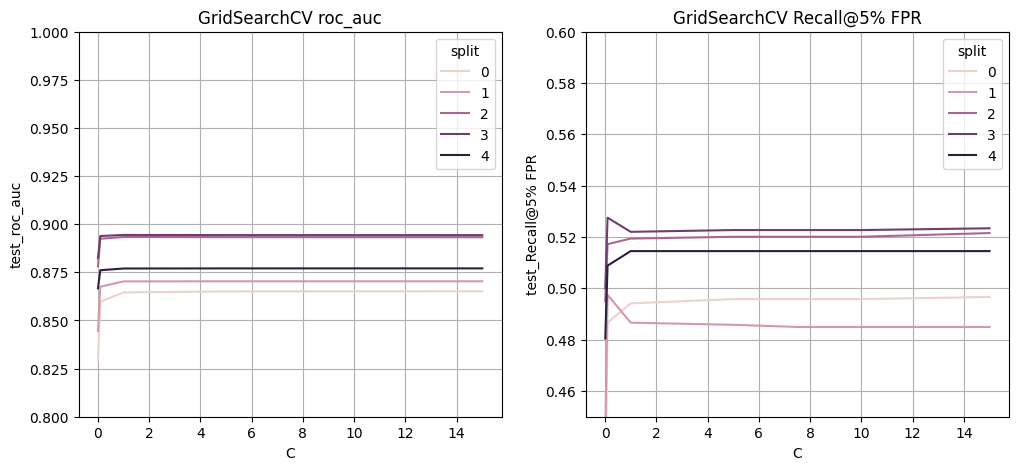

In [16]:
_res = gs_svc.cv_results_
_cv = cv_base

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_C'][i], _res[f'split{j}_test_roc_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['C', 'test_roc_auc', 'test_Recall@5% FPR', 'split'])

svc_base_res, svc_base_res_axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.lineplot(data=_df, x='C', y='test_roc_auc', ax=svc_base_res_axes[0], hue='split')
sns.lineplot(data=_df, x='C', y='test_Recall@5% FPR', ax=svc_base_res_axes[1], hue='split')

svc_base_res_axes[0].set_ylim((0.8, 1))
svc_base_res_axes[1].set_ylim((0.45, 0.6))

svc_base_res_axes[0].grid(True)
svc_base_res_axes[1].grid(True)

svc_base_res_axes[0].set_title('GridSearchCV roc_auc')
svc_base_res_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

Parameter C did not have a strong influence on the value of metrics, starting from C=1, so this value was chosen for training the model.

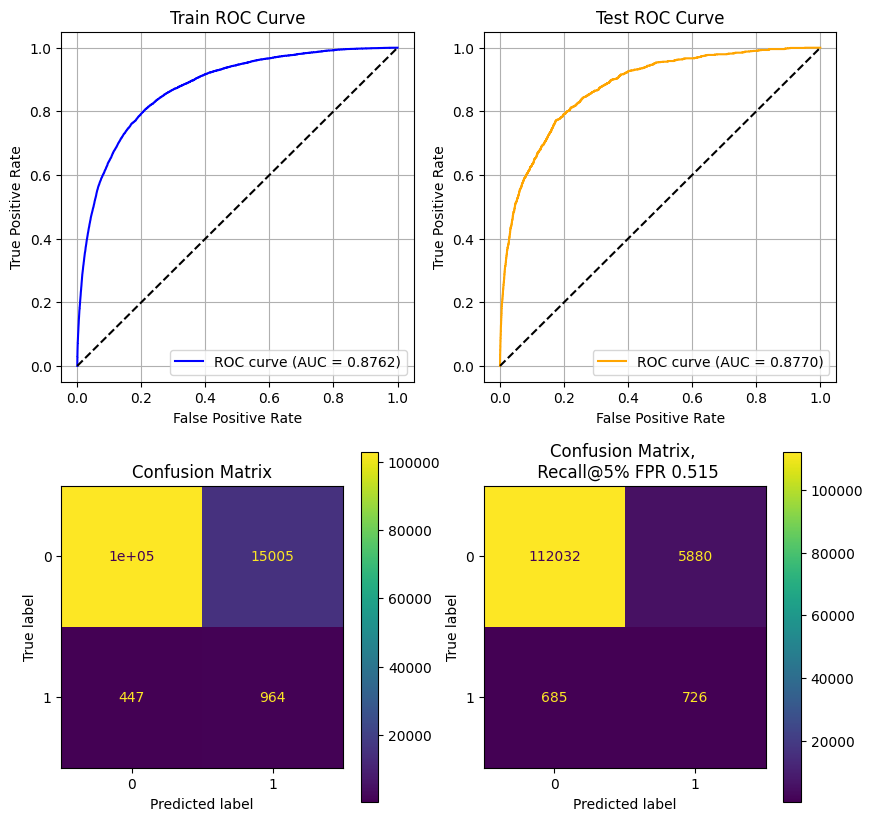

CPU times: total: 40.1 s
Wall time: 43.3 s


In [17]:
%%time

pipe_svc = Pipeline([
    ('preprocessor', dp_base),
    ('model', LinearSVC(class_weight='balanced', random_state=42, C=1)),
])

pipe_svc.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

fig_svc, axes_svc = model_report(
    pipe_svc,
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

I will remove unnecessary dataframes

In [18]:
del X_base, y_base, cv_base

# Add new features

## Preprocessing

In [19]:
%%time

custom_funcs = (
    ('similarity', ('device_os', ['customer_age', 'income'])),
    ('similarity', ('housing_status', ['customer_age', 'income'])),
)


dp = DataPreprocessor(
    cat_features=[
        'email_is_free', 'has_other_cards',  'keep_alive_session', 'phone_home_valid',  'phone_mobile_valid', 'device_os',
        'employment_status', 'customer_age', 'payment_type',  'housing_status', 'foreign_request',  'income', 'device_distinct_emails_8w',
        'proposed_credit_limit',
    ],
    num_features=[
        'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 
        'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'session_length_in_minutes', 'days_since_request', 
        'velocity_6h', 'velocity_24h', 'velocity_4w',
    ],
    custom_functions=custom_funcs,
    num_ohe_mte_threshold=5
)


preprocessor = Pipeline([
    ('none_handler', NoneHandler()),
    ('handler', DataHandler()),
    ('data_preprocessor', dp),
    ('iso', IsoForest(contamination='auto')),
])

X_cv_nf, y_cv_nf, cv_nf = preprocess(preprocessor, X_train, y_train)

s 2025-08-14 16:32:49.815144
Month 0 ended at 2025-08-14 16:32:55.597461, total 5 seconds
Month 1 ended at 2025-08-14 16:33:04.684510, total 9 seconds
Month 2 ended at 2025-08-14 16:33:16.746307, total 12 seconds
Month 3 ended at 2025-08-14 16:33:31.723691, total 14 seconds
Month 4 ended at 2025-08-14 16:33:48.517543, total 16 seconds

There are some Na values!!!

Columns with Na:
device_os_linux
device_os_other

CPU times: total: 53.4 s
Wall time: 59.2 s


There was a discrepancy because I combined the output dataframes of different preprocessors. Their results may differ slightly. I will fix this manually now to eliminate the empty column. This does not affect the cross-validation result and such problems will not occur during a normal model run.

In [20]:
X_cv_nf.loc[(X_cv_nf.device_os_linux.isna()) & (X_cv_nf.device_os_other==0), 'device_os_linux'] = 1
X_cv_nf.loc[(X_cv_nf.device_os_linux.isna()) & (X_cv_nf.device_os_other==1), 'device_os_linux'] = 0
X_cv_nf = X_cv_nf.drop('device_os_other', axis=1)

## SVC with new features

In [21]:
%%time

svc_nf = LinearSVC(class_weight='balanced', random_state=42)

Cs = [0.01, 0.1, 1.0, 5.0, 7.5, 10.0, 15]

gs_svc_nf = GridSearchCV(
    svc_nf, 
    param_grid={'C': Cs},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR',
    n_jobs=-1, 
    cv=cv_nf,
    return_train_score=True
)

gs_svc_nf.fit(X_cv_nf, y_cv_nf)

CPU times: total: 2min 30s
Wall time: 6min 36s


GridSearchCV(cv=[(RangeIndex(start=0, stop=132440, step=1),
                  RangeIndex(start=132440, stop=260060, step=1)),
                 (RangeIndex(start=260060, stop=520120, step=1),
                  RangeIndex(start=520120, stop=657099, step=1)),
                 (RangeIndex(start=657099, stop=1054138, step=1),
                  RangeIndex(start=1054138, stop=1205074, step=1)),
                 (RangeIndex(start=1205074, stop=1753049, step=1),
                  RangeIndex(start=1...
                 (RangeIndex(start=1880740, stop=2556406, step=1),
                  RangeIndex(start=2556406, stop=2675729, step=1))],
             estimator=LinearSVC(class_weight='balanced', random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1.0, 5.0, 7.5, 10.0, 15]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

In [22]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_svc_nf.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
4,{'C': 7.5},0.484870,0.511573,0.015599,0.499873,0.865863,0.880813,0.012191,0.871670
5,{'C': 10.0},0.484781,0.511573,0.015599,0.499873,0.865864,0.880817,0.012182,0.871681
6,{'C': 15},0.484893,0.511573,0.015599,0.499873,0.865865,0.880820,0.012174,0.871690
3,{'C': 5.0},0.484928,0.510928,0.015927,0.498983,0.865861,0.880806,0.012205,0.871652
2,{'C': 1.0},0.484913,0.509591,0.017258,0.496647,0.865785,0.880684,0.012381,0.871398
1,{'C': 0.1},0.479442,0.507481,0.017788,0.494140,0.864090,0.879045,0.013431,0.868971
0,{'C': 0.01},0.459335,0.484922,0.021822,0.468555,0.855069,0.870527,0.015895,0.858606


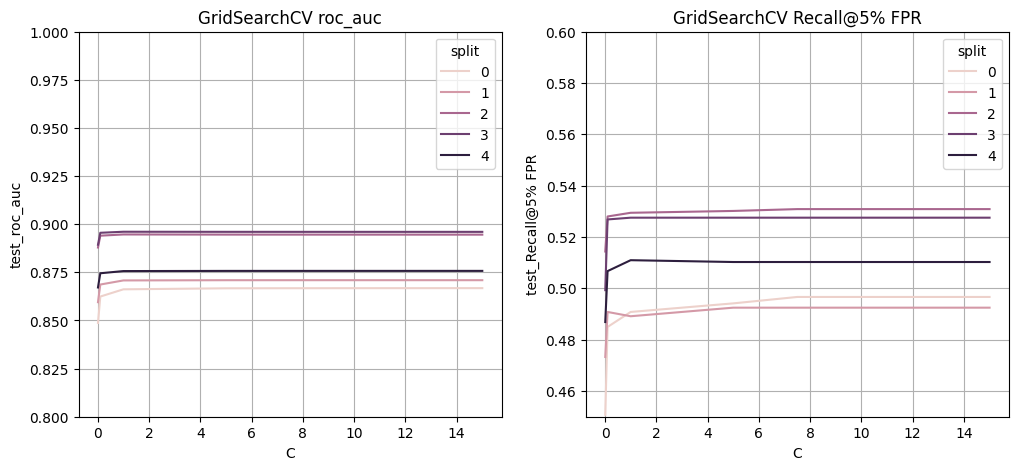

In [23]:
_res = gs_svc_nf.cv_results_
_cv = cv_nf

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_C'][i], _res[f'split{j}_test_roc_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['C', 'test_roc_auc', 'test_Recall@5% FPR', 'split'])

svc_nf_res, svc_nf_res_axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.lineplot(data=_df, x='C', y='test_roc_auc', ax=svc_nf_res_axes[0], hue='split')
sns.lineplot(data=_df, x='C', y='test_Recall@5% FPR', ax=svc_nf_res_axes[1], hue='split')

svc_nf_res_axes[0].set_ylim((0.8, 1))
svc_nf_res_axes[1].set_ylim((0.45, 0.6))

svc_nf_res_axes[0].grid(True)
svc_nf_res_axes[1].grid(True)

svc_nf_res_axes[0].set_title('GridSearchCV roc_auc')
svc_nf_res_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

Parameter C did not have a strong influence on the value of metrics again, starting from C=1, so this value was chosen for training the model.

CPU times: total: 1min 6s
Wall time: 1min 9s


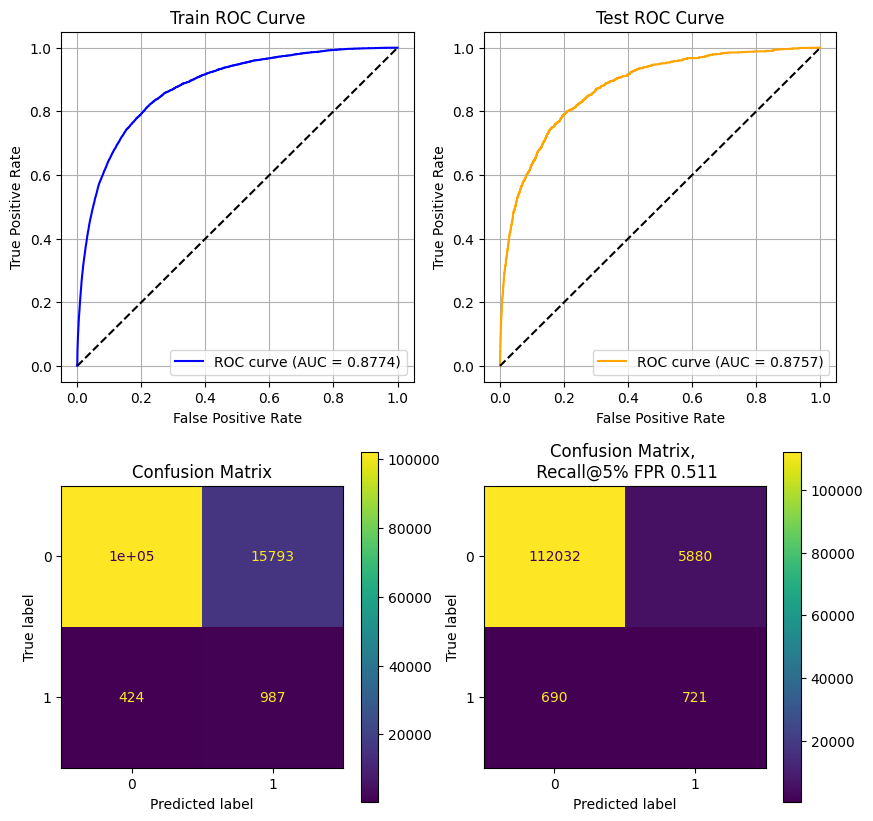

In [24]:
%%time

pipe_svc_nf = Pipeline([
    ('dp', preprocessor),
    ('model', LinearSVC(class_weight='balanced', random_state=42, C=1)),
])

pipe_svc_nf.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

fig_svc_nf, axes_svc_nf = model_report(
    pipe_svc_nf, 
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5]
)

## Random Forest

### Random Forest preprocessting

RandomForest involves training a large number of deep overfitted trees on bootstrap subsets. Training a large number of deep trees is very resource intensive. I will reduce the size of the training set by 2 times to speed up the process.

In [25]:
%%time

custom_funcs = (
    ('similarity', ('device_os', ['customer_age', 'income'])),
    ('similarity', ('housing_status', ['customer_age', 'income'])),
)


dp = DataPreprocessor(
    cat_features=[
        'email_is_free', 'has_other_cards',  'keep_alive_session', 'phone_home_valid',  'phone_mobile_valid', 'device_os',
        'employment_status', 'customer_age', 'payment_type',  'housing_status', 'foreign_request',  'income', 'device_distinct_emails_8w',
        'proposed_credit_limit',
    ],
    num_features=[
        'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'intended_balcon_amount', 
        'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'session_length_in_minutes', 'days_since_request', 
        'velocity_6h', 'velocity_24h', 'velocity_4w',
    ],
    custom_functions=custom_funcs,
    num_ohe_mte_threshold=5
)


preprocessor = Pipeline([
    ('none_handler', NoneHandler()),
    ('handler', DataHandler()),
    ('data_preprocessor', dp),
    ('iso', IsoForest(contamination='auto')),
])

CPU times: total: 0 ns
Wall time: 0 ns


In [26]:
%%time

list_df = []

for m in np.sort(X_train.month.unique()):
    _X_small, _, _, _ = train_test_split(
        X_train.loc[X_train.month==m], y_train.loc[X_train.month==m],
        train_size=0.5,
        stratify=y_train.loc[X_train.month==m],
        random_state=42
    )
    list_df.append(_X_small)

X_small = pd.concat(list_df, axis=0)
y_small = y_train.loc[X_small.index]

del _X_small, list_df, _    

X_cv_small, y_cv_small, cv_small = preprocess(preprocessor, X_small, y_small, return_transformers=False)

s 2025-08-14 16:41:36.637736
Month 0 ended at 2025-08-14 16:41:39.450400, total 2 seconds
Month 1 ended at 2025-08-14 16:41:43.619381, total 4 seconds
Month 2 ended at 2025-08-14 16:41:49.615741, total 5 seconds
Month 3 ended at 2025-08-14 16:41:57.004475, total 7 seconds
Month 4 ended at 2025-08-14 16:42:05.726525, total 8 seconds

There are some Na values!!!

Columns with Na:
device_os_linux
device_os_other

CPU times: total: 26.4 s
Wall time: 30 s


There was a discrepancy because I combined the output dataframes of different preprocessors. Their results may differ slightly. I will fix this manually now to eliminate the empty column. This does not affect the cross-validation result and such problems will not occur during a normal model run.

In [27]:
X_cv_small.loc[(X_cv_small.device_os_linux.isna()) & (X_cv_small.device_os_other==0), 'device_os_linux'] = 1
X_cv_small.loc[(X_cv_small.device_os_linux.isna()) & (X_cv_small.device_os_other==1), 'device_os_linux'] = 0
X_cv_small = X_cv_small.drop('device_os_other', axis=1)

### Tuning

Decision trees have many parameters to tune. Random forest inherits them. First, I'll check how the score changes when max_depth increases.

Parameter class_weight='balanced_subsample' to handle the imbalanced target classes.

In [28]:
%%time

forest_small = RandomForestClassifier(
    class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
    min_samples_leaf=1e-5,  min_impurity_decrease=1e-4, min_samples_split=5e-5, n_estimators=150,
)

max_depth = [35, 25, 20, 15, 10]

gs_forest_small = GridSearchCV(
    forest_small, 
    param_grid={'max_depth': max_depth},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR',    
    n_jobs=-1, 
    cv=cv_small,
    return_train_score=True,
)

gs_forest_small.fit(X_cv_small, y_cv_small)

CPU times: total: 16min 20s
Wall time: 9min 32s


GridSearchCV(cv=[(RangeIndex(start=0, stop=66220, step=1),
                  RangeIndex(start=66220, stop=130030, step=1)),
                 (RangeIndex(start=130030, stop=260060, step=1),
                  RangeIndex(start=260060, stop=328549, step=1)),
                 (RangeIndex(start=328549, stop=527068, step=1),
                  RangeIndex(start=527068, stop=602536, step=1)),
                 (RangeIndex(start=602536, stop=876523, step=1),
                  RangeIndex(start=876523, s...
                                              min_impurity_decrease=0.0001,
                                              min_samples_leaf=1e-05,
                                              min_samples_split=5e-05,
                                              n_estimators=150, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1, param_grid={'max_depth': [35, 25, 20, 15, 10]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

In [29]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_forest_small.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
0,{'max_depth': 35},1.000000,0.494000,0.022387,0.477210,0.997461,0.873254,0.022268,0.856552
1,{'max_depth': 25},1.000000,0.486236,0.020160,0.471116,0.997507,0.874584,0.021146,0.858724
2,{'max_depth': 20},1.000000,0.486530,0.027869,0.465628,0.997289,0.874023,0.020336,0.858771
3,{'max_depth': 15},0.991085,0.476580,0.018463,0.462733,0.994793,0.868874,0.021920,0.852434
4,{'max_depth': 10},0.787242,0.470496,0.015054,0.459205,0.962132,0.870585,0.018567,0.856659


As the max_depth increases, the quality increases, but already starting from max_depth=15, the model perfectly adapts to the training sample.

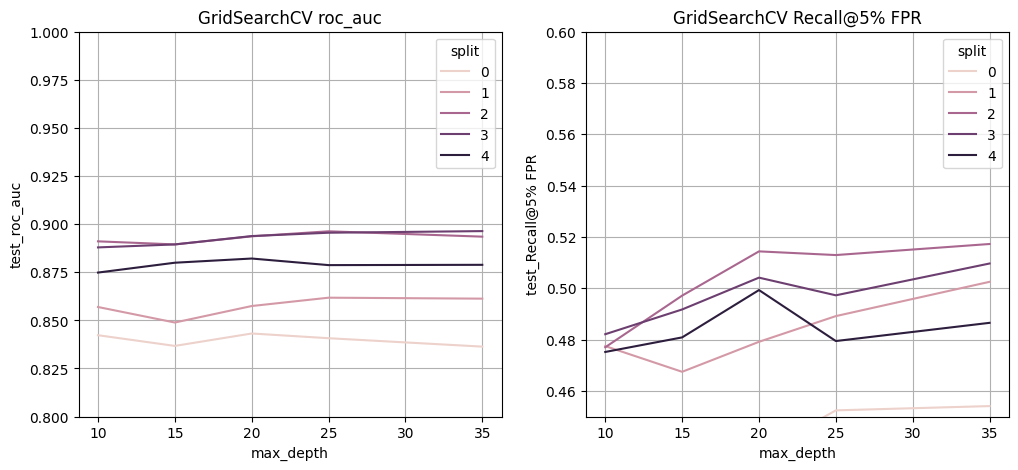

In [30]:
_res = gs_forest_small.cv_results_
_cv = cv_small

_df = []
for i in range(len(_res['params'])):
    for j in range(len(_cv)):
        _df.append([_res['param_max_depth'][i], _res[f'split{j}_test_roc_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['max_depth', 'test_roc_auc', 'test_Recall@5% FPR', 'split'])

forest_res, forest_axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.lineplot(data=_df, x='max_depth', y='test_roc_auc', ax=forest_axes[0], hue='split')
sns.lineplot(data=_df, x='max_depth', y='test_Recall@5% FPR', ax=forest_axes[1], hue='split')

forest_axes[0].set_ylim((0.8, 1))
forest_axes[1].set_ylim((0.45, 0.6))

forest_axes[0].grid(True)
forest_axes[1].grid(True)

forest_axes[0].set_title('GridSearchCV roc_auc')
forest_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

I will choose max_depth=25 as the optimal value and increase the values needed for splitting to prevent overfitting

In [31]:
%%time

forest_small_1 = RandomForestClassifier(
    class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
    min_impurity_decrease=1e-4, n_estimators=150, max_depth=25
)

min_samples_leaf = [1e-5, 5e-5, 1e-4]
min_samples_split = [5e-5, 5e-4]

gs_forest_small_1 = GridSearchCV(
    forest_small_1, 
    param_grid={'min_samples_leaf': min_samples_leaf, 'min_samples_split': min_samples_split},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR',    
    n_jobs=-1, 
    cv=cv_small,
    return_train_score=True,
)

gs_forest_small_1.fit(X_cv_small, y_cv_small)

CPU times: total: 16min 5s
Wall time: 11min 3s


GridSearchCV(cv=[(RangeIndex(start=0, stop=66220, step=1),
                  RangeIndex(start=66220, stop=130030, step=1)),
                 (RangeIndex(start=130030, stop=260060, step=1),
                  RangeIndex(start=260060, stop=328549, step=1)),
                 (RangeIndex(start=328549, stop=527068, step=1),
                  RangeIndex(start=527068, stop=602536, step=1)),
                 (RangeIndex(start=602536, stop=876523, step=1),
                  RangeIndex(start=876523, s...
                                              min_impurity_decrease=0.0001,
                                              n_estimators=150, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'min_samples_leaf': [1e-05, 5e-05, 0.0001],
                         'min_samples_split': [5e-05, 0.0005]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

It was possible to increase the quality a little on the test, while on the train the quality is no longer equal to 1

In [32]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_forest_small_1.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
3,"{'min_samples_leaf': 5e-05, 'min_samples_split...",0.986149,0.500603,0.008760,0.494033,0.992241,0.880099,0.015251,0.868661
1,"{'min_samples_leaf': 1e-05, 'min_samples_split...",0.989473,0.497170,0.013553,0.487005,0.993062,0.879074,0.016359,0.866805
5,"{'min_samples_leaf': 0.0001, 'min_samples_spli...",0.973156,0.497787,0.017299,0.484813,0.990667,0.877992,0.018512,0.864107
4,"{'min_samples_leaf': 0.0001, 'min_samples_spli...",0.996067,0.496641,0.018181,0.483005,0.993789,0.878662,0.017015,0.865900
2,"{'min_samples_leaf': 5e-05, 'min_samples_split...",1.000000,0.496780,0.021584,0.480592,0.996392,0.876497,0.019154,0.862132
0,"{'min_samples_leaf': 1e-05, 'min_samples_split...",1.000000,0.486236,0.020160,0.471116,0.997507,0.874584,0.021146,0.858724


For now, I will select the parameters that showed the best results in cross-validation, despite the fact that the model is overfitted. In the next section, parameter enumeration will be carried out using Optun, where more attention will be paid to selecting the best parameters.

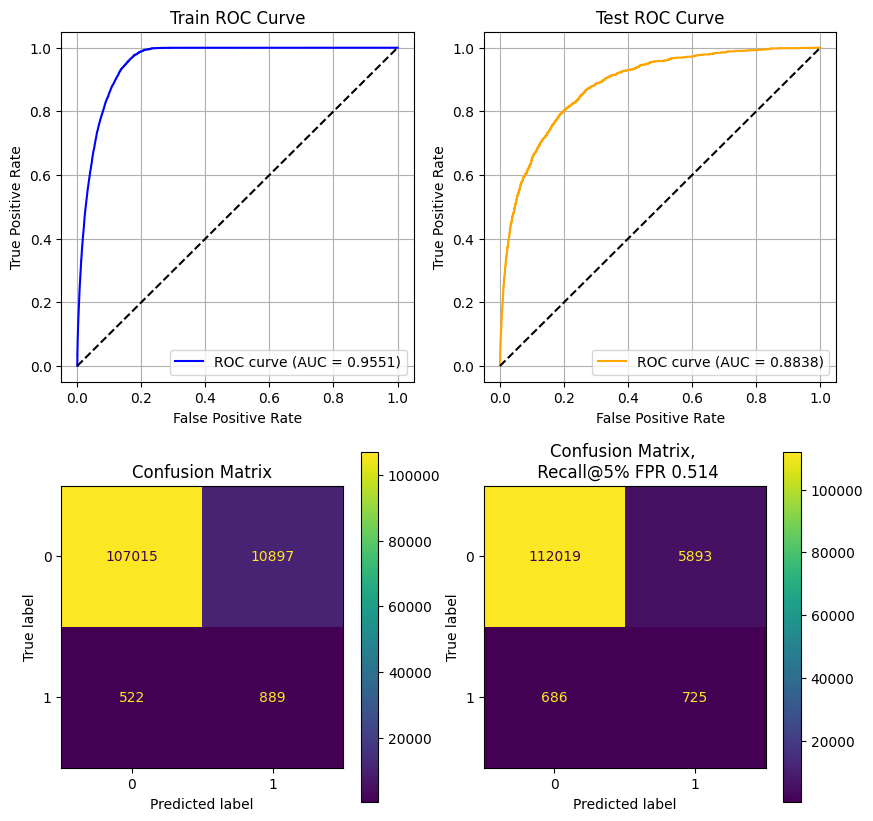

CPU times: total: 11min 52s
Wall time: 2min 27s


In [33]:
%%time

pipe_forest = Pipeline([
    ('dp', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
        min_impurity_decrease=1e-4, n_estimators=250, max_depth=25, min_samples_leaf=1e-4, min_samples_split = 5e-4,
    )),
])

pipe_forest.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

fig_forest, axes_forest = model_report(
    pipe_forest,
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

## XGBoost

XGBoost is based on training a huge number of low depth decision trees that correct each other's errors. 

To start with, I'll go through the parameters max_depth and n_estimators.

Other parameters are fixed. The negative to positive class ratio in the whole train sample is passed to the parameter 'scale_pos_weight'.

In [34]:
%%time

xgb_params_gs = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.04,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.05, 
    'gamma': 0.05,
    'reg_alpha': 0.75,
    'reg_lambda': 1e-3,
    'eval_metric': 'logloss'
}

xgb_gs = XGBClassifier(**xgb_params_gs)


n_estimators = [200, 350, 600, 800]
max_depth = [2, 5, 8]


gs_xgb = GridSearchCV(
    xgb_gs, 
    param_grid={'n_estimators': n_estimators, 'max_depth': max_depth},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_nf,
    return_train_score=True
)

gs_xgb.fit(X_cv_nf, y_cv_nf)

CPU times: total: 6min 50s
Wall time: 10min 39s


GridSearchCV(cv=[(RangeIndex(start=0, stop=132440, step=1),
                  RangeIndex(start=132440, stop=260060, step=1)),
                 (RangeIndex(start=260060, stop=520120, step=1),
                  RangeIndex(start=520120, stop=657099, step=1)),
                 (RangeIndex(start=657099, stop=1054138, step=1),
                  RangeIndex(start=1054138, stop=1205074, step=1)),
                 (RangeIndex(start=1205074, stop=1753049, step=1),
                  RangeIndex(start=1...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [2, 5, 8],
                         'n_estimators': [200, 350, 600, 800]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

In [35]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(gs_xgb.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
2,"{'max_depth': 2, 'n_estimators': 600}",0.544807,0.551565,0.019252,0.537126,0.896273,0.896154,0.012758,0.886586
3,"{'max_depth': 2, 'n_estimators': 800}",0.553881,0.553195,0.022647,0.536210,0.900644,0.896785,0.012980,0.887050
1,"{'max_depth': 2, 'n_estimators': 350}",0.525443,0.538674,0.019674,0.523919,0.888147,0.893122,0.012610,0.883664
5,"{'max_depth': 5, 'n_estimators': 350}",0.670121,0.536250,0.028100,0.515175,0.942820,0.891821,0.016240,0.879642
4,"{'max_depth': 5, 'n_estimators': 200}",0.611642,0.534090,0.025704,0.514812,0.924985,0.892050,0.015206,0.880645
0,"{'max_depth': 2, 'n_estimators': 200}",0.499739,0.519826,0.018747,0.505765,0.878174,0.887050,0.012576,0.877618
6,"{'max_depth': 5, 'n_estimators': 600}",0.754764,0.523699,0.034454,0.497858,0.960153,0.887903,0.018849,0.873767
7,"{'max_depth': 5, 'n_estimators': 800}",0.811496,0.518586,0.038027,0.490066,0.969265,0.885268,0.020178,0.870134
8,"{'max_depth': 8, 'n_estimators': 200}",0.887965,0.496847,0.032294,0.472626,0.980745,0.878669,0.020676,0.863162
9,"{'max_depth': 8, 'n_estimators': 350}",0.963972,0.481014,0.038249,0.452327,0.991200,0.870698,0.023999,0.852698


The score of XGBoost with parameters max_depth=2 and n_estimators=800 is better than the best score of RandomForest. The model is not overfitted (the difference between train and test score is small).

Trees with less depth perfors better than deeper. As the number of estimators increases, the score improves.

The models with max_depth=8 (especially with a large n_estimators) are overfitted.

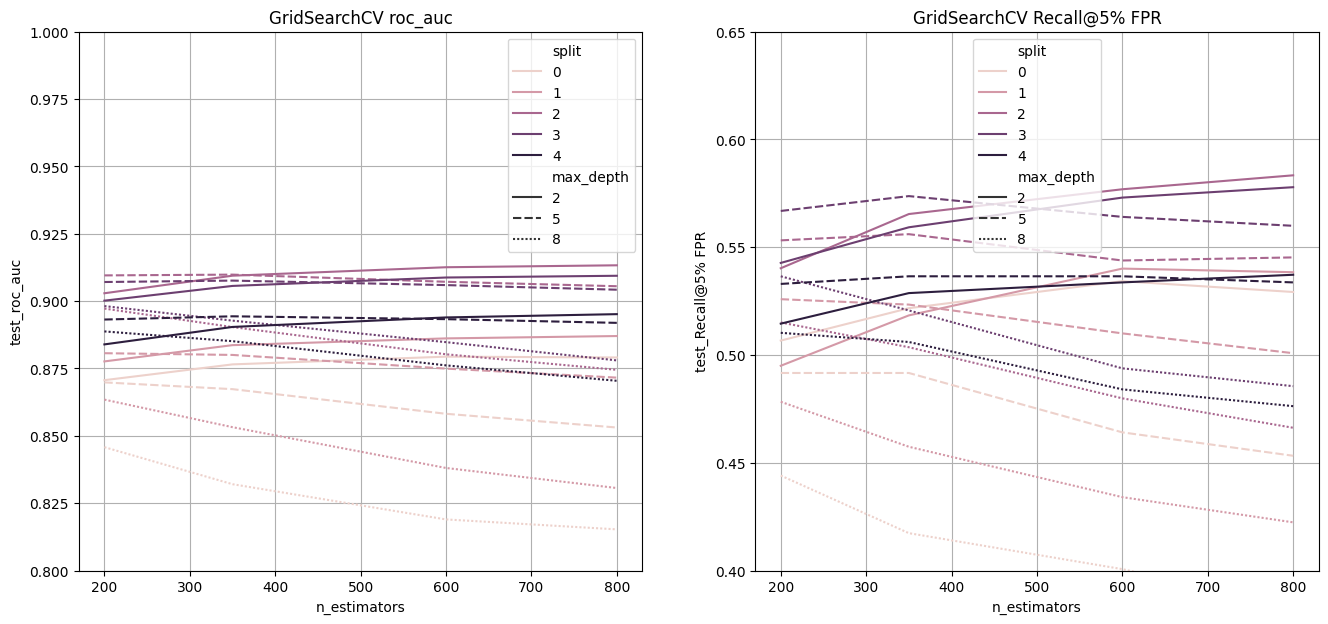

In [36]:
_res = gs_xgb.cv_results_

_df = []
for i in range(len(_res['params'])):
    for j in range(len(cv_nf)):
        _df.append([_res['param_n_estimators'][i], _res['param_max_depth'][i], _res[f'split{j}_test_roc_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['n_estimators', 'max_depth', 'test_roc_auc', 'test_Recall@5% FPR', 'split'])

xgb_res, xgb_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

sns.lineplot(data=_df, x='n_estimators', y='test_roc_auc', ax=xgb_axes[0], hue='split', style='max_depth')
sns.lineplot(data=_df, x='n_estimators', y='test_Recall@5% FPR', ax=xgb_axes[1], hue='split', style='max_depth')

xgb_axes[0].set_ylim((0.8, 1))
xgb_axes[1].set_ylim((0.4, 0.65))

xgb_axes[0].grid(True)
xgb_axes[1].grid(True)

xgb_axes[0].set_title('GridSearchCV roc_auc')
xgb_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

I'll try to increase max_depth up to 3 to get some space for the model, I'll also decrease n_estimators to 600 to prevent overfitting

In [37]:
%%time

xgb_params = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'n_estimators': 600,
    'max_depth': 3,
    'learning_rate': 0.04,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.05, 
    'gamma': 0.05,
    'reg_alpha': 0.75,
    'reg_lambda': 1e-3,
    'eval_metric': 'logloss',
    'seed': 42,    
}

xgb = XGBClassifier(**xgb_params)

xgb_cv = cross_validate(
    xgb,
    X_cv_nf, y_cv_nf, 
    scoring={'roc_auc': 'roc_auc', 
               'Recall@5% FPR': recall_a5_fpr},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
)

CPU times: total: 2.38 s
Wall time: 1min 15s


In [38]:
print('Recall_metric:', xgb_cv['test_Recall@5% FPR'].mean() - xgb_cv['test_Recall@5% FPR'].std() * 0.75)
print('roc_auc_metric:',xgb_cv['test_roc_auc'].mean() - xgb_cv['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(xgb_cv)

Recall_metric: 0.5330464614153444
roc_auc_metric: 0.8861191279709724



,fit_time,score_time,estimator,test_roc_auc,train_roc_auc,test_Recall@5% FPR,train_Recall@5% FPR
0,12.523824,0.740170,"XGBClassifier(base_score=None, booster='gbtree...",0.877452,0.929078,0.525876,0.585333
1,24.955628,0.790180,"XGBClassifier(base_score=None, booster='gbtree...",0.885506,0.914520,0.535893,0.581542
2,39.436894,0.858193,"XGBClassifier(base_score=None, booster='gbtree...",0.912869,0.908647,0.581897,0.569815
3,52.410821,0.716160,"XGBClassifier(base_score=None, booster='gbtree...",0.909283,0.909986,0.574380,0.572050
4,69.584693,0.665362,"XGBClassifier(base_score=None, booster='gbtree...",0.896211,0.910382,0.533664,0.576261


Compare with the best model on GridSearch

In [39]:
pd.DataFrame(gs_xgb.cv_results_).loc[3]

mean_fit_time                                             48.995529
std_fit_time                                              25.208706
mean_score_time                                            0.652546
std_score_time                                             0.080596
param_max_depth                                                   2
param_n_estimators                                              800
params                        {'max_depth': 2, 'n_estimators': 800}
split0_test_roc_auc                                        0.879076
split1_test_roc_auc                                        0.887029
split2_test_roc_auc                                        0.913276
split3_test_roc_auc                                        0.909392
split4_test_roc_auc                                        0.895151
mean_test_roc_auc                                          0.896785
std_test_roc_auc                                            0.01298
rank_test_roc_auc                               

Train the model with the best parameters

In [40]:
%%time

xgb_params = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'n_estimators': 800,
    'max_depth': 2,
    'learning_rate': 0.04,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.05, 
    'gamma': 0.05,
    'reg_alpha': 0.75,
    'reg_lambda': 1e-3,
    'eval_metric': 'logloss',
    'seed': 42,    
}

xgb = XGBClassifier(**xgb_params)


pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb),
])

pipe_xgb.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])

CPU times: total: 1min 49s
Wall time: 31.4 s


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('none_handler', NoneHandler()),
                                 ('handler', DataHandler()),
                                 ('data_preprocessor',
                                  DataPreprocessor(cat_features=['email_is_free',
                                                                 'has_other_cards',
                                                                 'keep_alive_session',
                                                                 'phone_home_valid',
                                                                 'phone_mobile_valid',
                                                                 'device_os',
                                                                 'employment_status',
                                                                 'customer_age',
                                                                 'payment_type',
                                                                 'housing_status',
                                                                 'foreign_request',
                                                                 '...
                               feature_types=None, feature_weights=None,
                               gamma=0.05, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.04,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=0.05, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=800, n_jobs=None,
                               num_parallel_tree=None, ...))])

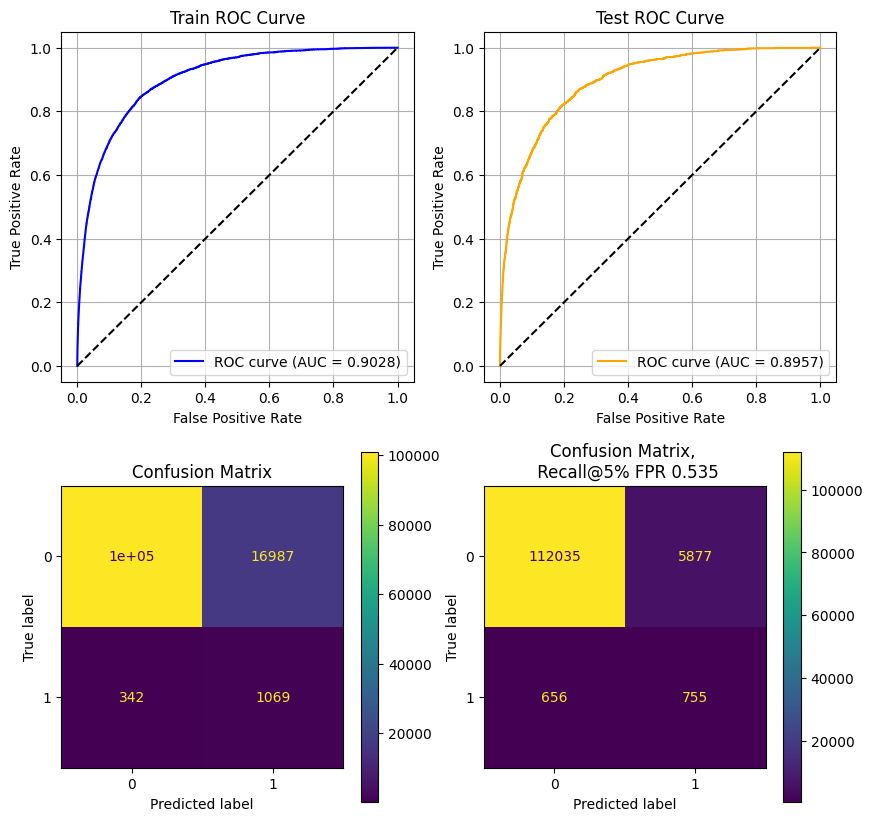

In [41]:
fig_xgb, axes_xgb = model_report(
    pipe_xgb, 
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)
plt.show()

# Undersampling, oversampling (NearMiss & SMOTE)

The target class is very unbalanced. I'll try to use methods from the imbalanced-learn. I will write a small class to preprocess to drop some negative objects and add some positive ones. It takes two parameters:
- final_pos_rate - the ratio of positive objects to all objects after transformation
- synt_rate - the ratio of synthesized positive objects to all positive after transformation

In [42]:
def imb_preprocess(X, y, cv=None, final_pos_rate=0.1, synt_rate=0.8):
    
    smote_strat = final_pos_rate / (1 - final_pos_rate)
    nm_strat = (1 - synt_rate) * smote_strat

    x_list = []
    y_list = []
    new_cv = []
    last_index = 0
    
    if cv is None:
        cv = ((X.index), (X.index))

    t = datetime.datetime.now()
    print('s', t)

    for i, split in enumerate(cv):

        nm = NearMiss(
            sampling_strategy=nm_strat, 
            n_jobs=-1,
        )
        smote = SMOTE(
            sampling_strategy=smote_strat, 
            random_state=42,
        )
        
        pipe_imb = ImbPipeline([
            ('nm', nm),
            ('smote', smote),
        ])

        _x, _y = pipe_imb.fit_resample(X.loc[split[0]], y.loc[split[0]])
        
        x_list.append(_x)
        y_list.append(_y)
        x_list.append(X.loc[split[1]])
        y_list.append(y.loc[split[1]])

        new_cv.append(
            (
                pd.RangeIndex(start=last_index, stop=last_index+len(_x)), 
                pd.RangeIndex(start=last_index+len(_x), stop=last_index+len(_x)+len(X.loc[split[1]])),
            )
        )

        last_index = last_index+len(_x)+len(X.loc[split[1]])

        delta = int((datetime.datetime.now() - t).total_seconds())
        t = datetime.datetime.now()
        
        print(f"Split {i} ended at {t}, total {delta} seconds")
        

    X_transformed = pd.concat(x_list, axis=0, ignore_index=True)
    y_transformed = pd.concat(y_list, axis=0, ignore_index=True)

    return X_transformed, y_transformed, new_cv

The parameters must be in the acceptable range, and their combination will greatly affect the final size of the dataset.

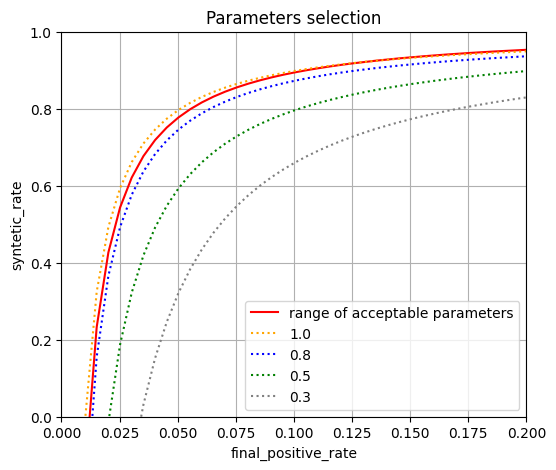

In [43]:
max_rate = 1e-3

for m in X_train.month.unique():
    if np.sum(y_train[X_train.month==m]) / np.sum(X_train.month==m) > max_rate:
        max_rate = np.sum(y_train[X_train.month==m]) / np.sum(X_train.month==m)

avg_rate = np.sum(y_train) / len(y_train)

fin_rates_ax = np.linspace(1e-4, 1-1e-4, 200)

plt.figure(figsize=(6,5))

sns.lineplot(x=fin_rates_ax, y=(1 + max_rate - max_rate / fin_rates_ax), linestyle='-', color='r', label='range of acceptable parameters')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax), linestyle=':', color='orange', label='1.0')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax / 0.8),  linestyle=':', color='b', label='0.8')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax / 0.5),  linestyle=':', color='g', label='0.5')
sns.lineplot(x=fin_rates_ax, y=(1 - avg_rate / fin_rates_ax / 0.3),  linestyle=':', color='gray', label='0.3')

plt.xlabel('final_positive_rate')
plt.ylabel('syntetic_rate')

plt.xlim((0, 0.2))
plt.ylim((0, 1))
plt.grid(True)
plt.legend()
plt.title('Parameters selection')

plt.show()

In [44]:
final_pos_rate=0.1
synt_rate=0.8

print(f"When using imbalanced learning with parameters: final_pos_rate={final_pos_rate} and synt_rate={synt_rate}, the train part will be {(np.sum(y_train) / len(y_train) / final_pos_rate / (1 - synt_rate)):.1%} of the original")

When using imbalanced learning with parameters: final_pos_rate=0.1 and synt_rate=0.8, the train part will be 51.3% of the original


In [45]:
%%time
X_imb, y_imb, cv_imb = imb_preprocess(X_cv_nf, y_cv_nf, cv=cv_nf, final_pos_rate=0.1, synt_rate=0.8)

s 2025-08-14 17:17:51.332072
Split 0 ended at 2025-08-14 17:17:52.079262, total 0 seconds
Split 1 ended at 2025-08-14 17:17:53.301539, total 1 seconds
Split 2 ended at 2025-08-14 17:17:55.576051, total 2 seconds
Split 3 ended at 2025-08-14 17:17:59.236877, total 3 seconds
Split 4 ended at 2025-08-14 17:18:04.516067, total 5 seconds
CPU times: total: 57.8 s
Wall time: 13.3 s


I will strengthen the regularization to prevent overfitting

In [46]:
%%time

imb_xgb_params_gs = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.04,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.1, 
    'gamma': 0.05,
    'reg_alpha': 0.9,
    'reg_lambda': 1e-2,
    'eval_metric': 'logloss',
    'seed': 42,
}

imb_xgb = XGBClassifier(**imb_xgb_params_gs)


n_estimators = [100, 250, 400, 600]
max_depth = [1, 2, 3]


imb_gs_xgb = GridSearchCV(
    imb_xgb, 
    param_grid={'n_estimators': n_estimators, 'max_depth': max_depth},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_imb,
    return_train_score=True
)

imb_gs_xgb.fit(X_imb, y_imb)

CPU times: total: 2min 4s
Wall time: 3min


GridSearchCV(cv=[(RangeIndex(start=0, stop=75000, step=1),
                  RangeIndex(start=75000, stop=202620, step=1)),
                 (RangeIndex(start=202620, stop=337520, step=1),
                  RangeIndex(start=337520, stop=474499, step=1)),
                 (RangeIndex(start=474499, stop=669299, step=1),
                  RangeIndex(start=669299, stop=820235, step=1)),
                 (RangeIndex(start=820235, stop=1084635, step=1),
                  RangeIndex(start=1084635...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3],
                         'n_estimators': [100, 250, 400, 600]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

In [47]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(imb_gs_xgb.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
2,"{'max_depth': 1, 'n_estimators': 400}",0.699275,0.459137,0.012219,0.449973,0.935817,0.866232,0.011687,0.857467
3,"{'max_depth': 1, 'n_estimators': 600}",0.740641,0.455370,0.015422,0.443803,0.944922,0.864740,0.012490,0.855373
1,"{'max_depth': 1, 'n_estimators': 250}",0.652857,0.452167,0.012215,0.443006,0.924280,0.865209,0.012103,0.856132
5,"{'max_depth': 2, 'n_estimators': 250}",0.802064,0.426749,0.013619,0.416535,0.957841,0.857341,0.013968,0.846864
8,"{'max_depth': 3, 'n_estimators': 100}",0.763441,0.406380,0.010475,0.398524,0.950616,0.849675,0.013952,0.839211
4,"{'max_depth': 2, 'n_estimators': 100}",0.688766,0.401725,0.015470,0.390123,0.932236,0.849971,0.012926,0.840276
6,"{'max_depth': 2, 'n_estimators': 400}",0.845541,0.408108,0.025286,0.389144,0.966526,0.854127,0.015037,0.842849
0,"{'max_depth': 1, 'n_estimators': 100}",0.562041,0.400251,0.019066,0.385952,0.897461,0.838724,0.015791,0.826881
9,"{'max_depth': 3, 'n_estimators': 250}",0.863073,0.400491,0.027351,0.379978,0.970104,0.849110,0.015650,0.837373
7,"{'max_depth': 2, 'n_estimators': 600}",0.875772,0.377403,0.031164,0.354031,0.972540,0.848325,0.015931,0.836377


Overfitted models (e.g. max_depth=3, n_estimators=600) showed the worst result. Trees with depth 1 showed the best result, but it is worse than without oversampling and undersampling.

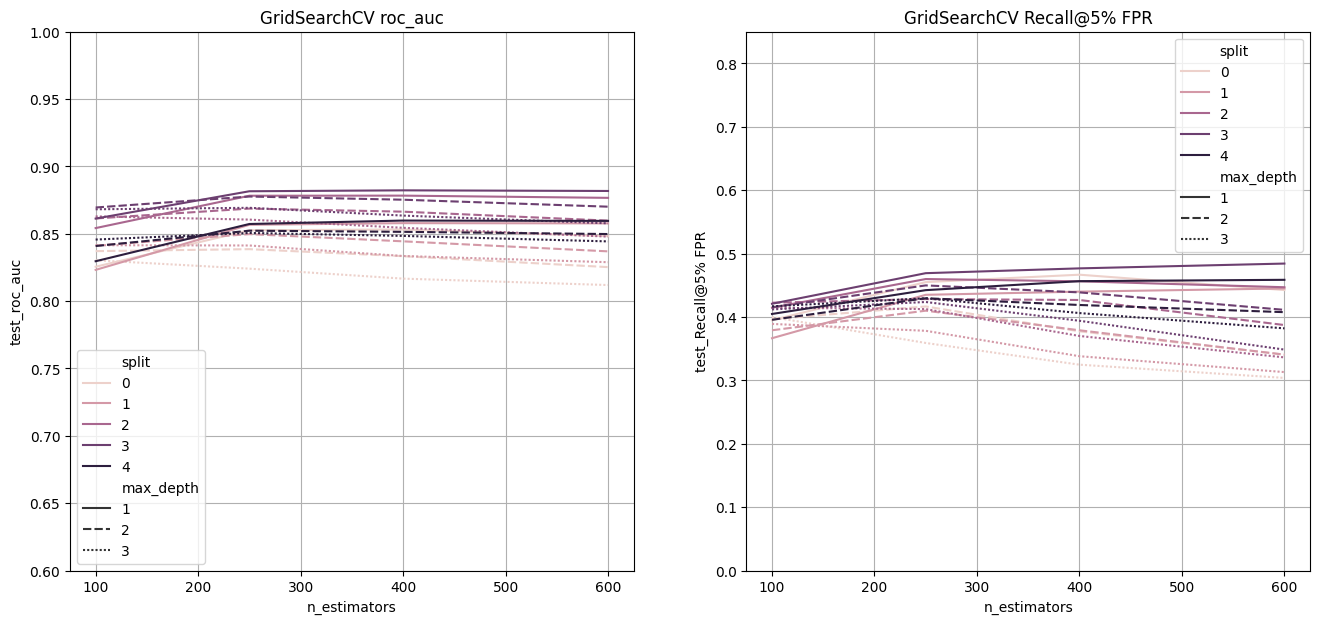

In [48]:
_res = imb_gs_xgb.cv_results_

_df = []
for i in range(len(_res['params'])):
    for j in range(len(cv_imb)):
        _df.append([_res['param_n_estimators'][i], _res['param_max_depth'][i], _res[f'split{j}_test_roc_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['n_estimators', 'max_depth', 'test_roc_auc', 'test_Recall@5% FPR', 'split'])

imb_xgb_res, imb_xgb_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

sns.lineplot(data=_df, x='n_estimators', y='test_roc_auc', ax=imb_xgb_axes[0], hue='split', style='max_depth')
sns.lineplot(data=_df, x='n_estimators', y='test_Recall@5% FPR', ax=imb_xgb_axes[1], hue='split', style='max_depth')

imb_xgb_axes[0].set_ylim((0.6, 1))
imb_xgb_axes[1].set_ylim((0.0, 0.85))

imb_xgb_axes[0].grid(True)
imb_xgb_axes[1].grid(True)

imb_xgb_axes[0].set_title('GridSearchCV roc_auc')
imb_xgb_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

In [49]:
final_pos_rate=0.05
synt_rate=0.75

print(f"When using imbalanced learning with parameters: final_pos_rate={final_pos_rate} and synt_rate={synt_rate}, the train part will be {(np.sum(y_train) / len(y_train) / final_pos_rate / (1 - synt_rate)):.1%} of the original")

When using imbalanced learning with parameters: final_pos_rate=0.05 and synt_rate=0.75, the train part will be 82.0% of the original


Perhaps increasing the target class share by 10x increased the tendency to overfit. I will change the sampling parameters

In [50]:
%%time
X_imb, y_imb, cv_imb = imb_preprocess(X_cv_nf, y_cv_nf, cv=cv_nf, final_pos_rate=0.05, synt_rate=0.75)

s 2025-08-14 17:21:05.956456
Split 0 ended at 2025-08-14 17:21:06.564591, total 0 seconds
Split 1 ended at 2025-08-14 17:21:07.915896, total 1 seconds
Split 2 ended at 2025-08-14 17:21:10.334442, total 2 seconds
Split 3 ended at 2025-08-14 17:21:14.253326, total 3 seconds
Split 4 ended at 2025-08-14 17:21:19.985626, total 5 seconds
CPU times: total: 59 s
Wall time: 14.3 s


In [51]:
%%time

imb_xgb_params_gs_1 = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.04,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.1, 
    'gamma': 0.05,
    'reg_alpha': 0.9,
    'reg_lambda': 1e-2,
    'eval_metric': 'logloss',
    'seed': 42,
}

imb_xgb_1 = XGBClassifier(**imb_xgb_params_gs_1)


n_estimators = [100, 250, 400, 600]
max_depth = [1, 2, 3]


imb_gs_xgb_1 = GridSearchCV(
    imb_xgb_1, 
    param_grid={'n_estimators': n_estimators, 'max_depth': max_depth},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_imb,
    return_train_score=True
)

imb_gs_xgb_1.fit(X_imb, y_imb)

CPU times: total: 3min 48s
Wall time: 4min 45s


GridSearchCV(cv=[(RangeIndex(start=0, stop=119998, step=1),
                  RangeIndex(start=119998, stop=247618, step=1)),
                 (RangeIndex(start=247618, stop=463456, step=1),
                  RangeIndex(start=463456, stop=600435, step=1)),
                 (RangeIndex(start=600435, stop=912115, step=1),
                  RangeIndex(start=912115, stop=1063051, step=1)),
                 (RangeIndex(start=1063051, stop=1486089, step=1),
                  RangeIndex(start=148...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3],
                         'n_estimators': [100, 250, 400, 600]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

In [52]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(imb_gs_xgb_1.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
10,"{'max_depth': 3, 'n_estimators': 400}",0.863465,0.520829,0.013367,0.510804,0.969847,0.887411,0.010798,0.879312
11,"{'max_depth': 3, 'n_estimators': 600}",0.879288,0.520303,0.014272,0.509599,0.973894,0.887726,0.011101,0.879400
7,"{'max_depth': 2, 'n_estimators': 600}",0.850346,0.516828,0.011288,0.508362,0.966269,0.887247,0.010412,0.879438
6,"{'max_depth': 2, 'n_estimators': 400}",0.829247,0.510620,0.009495,0.503499,0.961498,0.885158,0.010462,0.877312
9,"{'max_depth': 3, 'n_estimators': 250}",0.837831,0.507737,0.015086,0.496422,0.964091,0.884509,0.010254,0.876819
3,"{'max_depth': 1, 'n_estimators': 600}",0.729813,0.502754,0.011451,0.494166,0.940641,0.881880,0.010940,0.873675
2,"{'max_depth': 1, 'n_estimators': 400}",0.698223,0.495409,0.012499,0.486034,0.933501,0.878357,0.010281,0.870646
5,"{'max_depth': 2, 'n_estimators': 250}",0.795514,0.493170,0.011357,0.484652,0.954504,0.880460,0.010545,0.872551
1,"{'max_depth': 1, 'n_estimators': 250}",0.666567,0.477171,0.013187,0.467281,0.925741,0.872404,0.010295,0.864683
8,"{'max_depth': 3, 'n_estimators': 100}",0.775119,0.459833,0.011429,0.451261,0.950016,0.872302,0.009684,0.865039


Now more complex models show better scores. If I increase the number of estimators, the models may show better results, but not much

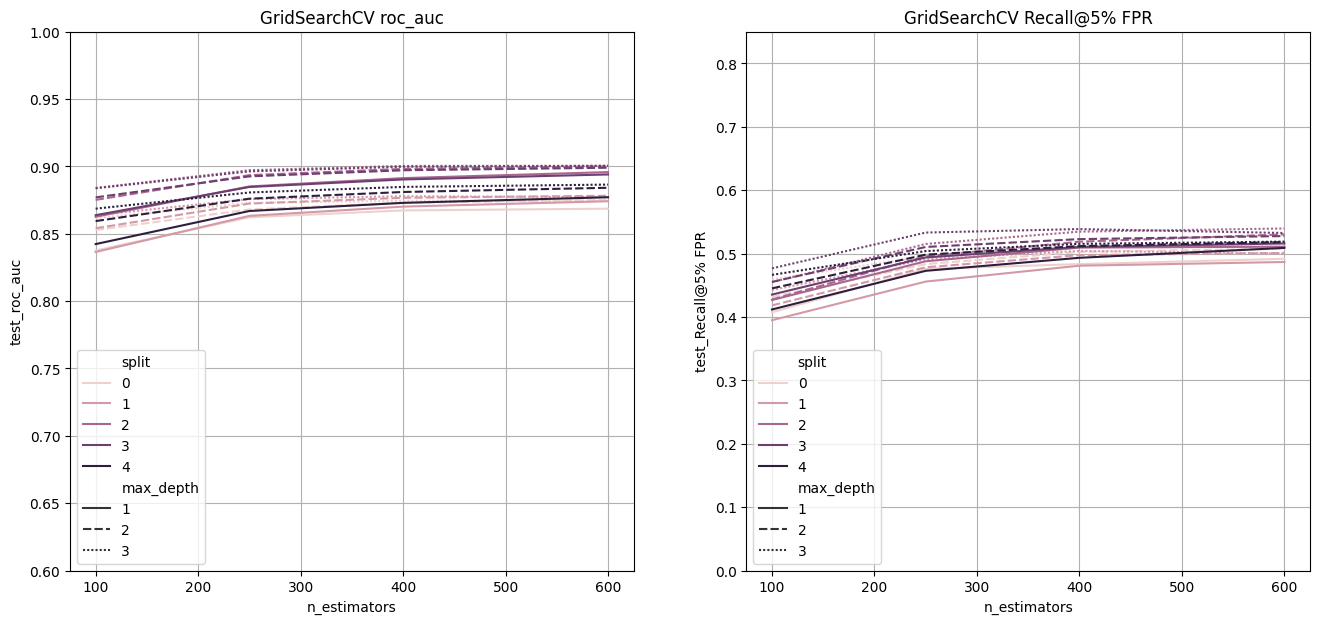

In [53]:
_res = imb_gs_xgb_1.cv_results_

_df = []
for i in range(len(_res['params'])):
    for j in range(len(cv_imb)):
        _df.append([_res['param_n_estimators'][i], _res['param_max_depth'][i], _res[f'split{j}_test_roc_auc'][i], _res[f'split{j}_test_Recall@5% FPR'][i], j])

_df = pd.DataFrame(_df, columns=['n_estimators', 'max_depth', 'test_roc_auc', 'test_Recall@5% FPR', 'split'])

imb_xgb_res, imb_xgb_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

sns.lineplot(data=_df, x='n_estimators', y='test_roc_auc', ax=imb_xgb_axes[0], hue='split', style='max_depth')
sns.lineplot(data=_df, x='n_estimators', y='test_Recall@5% FPR', ax=imb_xgb_axes[1], hue='split', style='max_depth')

imb_xgb_axes[0].set_ylim((0.6, 1))
imb_xgb_axes[1].set_ylim((0.0, 0.85))

imb_xgb_axes[0].grid(True)
imb_xgb_axes[1].grid(True)

imb_xgb_axes[0].set_title('GridSearchCV roc_auc')
imb_xgb_axes[1].set_title('GridSearchCV Recall@5% FPR')

plt.show()

I'll try to change the regularization strength

In [54]:
%%time

imb_xgb_params_gs_2 = {
    'booster':'gbtree',
    'scale_pos_weight': (len(y_train) - np.sum(y_train)) / np.sum(y_train), 
    'learning_rate': 0.04,
    'subsample': 0.9,
    'colsample_bytree': 0.5, 
    'min_child_weight': 0.1, 
    'gamma': 0.05,
    'reg_alpha': 0.9,
    'reg_lambda': 1e-2,
    'eval_metric': 'logloss',
    'seed': 42,
    'n_estimators': 400
}

imb_xgb_2 = XGBClassifier(**imb_xgb_params_gs_2)


max_depth = [2, 3]
reg_alpha = [0.75, 0.9]
min_child_weight = [0.05, 0.1]


imb_gs_xgb_2 = GridSearchCV(
    imb_xgb_2, 
    param_grid={'min_child_weight': min_child_weight, 'reg_alpha': reg_alpha, 'max_depth': max_depth},
    scoring={'roc_auc': 'roc_auc', 
             'Recall@5% FPR': recall_a5_fpr},
    refit='Recall@5% FPR', 
    n_jobs=-1, 
    cv=cv_imb,
    return_train_score=True
)

imb_gs_xgb_2.fit(X_imb, y_imb)

CPU times: total: 3min 53s
Wall time: 4min 1s


GridSearchCV(cv=[(RangeIndex(start=0, stop=119998, step=1),
                  RangeIndex(start=119998, stop=247618, step=1)),
                 (RangeIndex(start=247618, stop=463456, step=1),
                  RangeIndex(start=463456, stop=600435, step=1)),
                 (RangeIndex(start=600435, stop=912115, step=1),
                  RangeIndex(start=912115, stop=1063051, step=1)),
                 (RangeIndex(start=1063051, stop=1486089, step=1),
                  RangeIndex(start=148...
                                     multi_strategy=None, n_estimators=400,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3], 'min_child_weight': [0.05, 0.1],
                         'reg_alpha': [0.75, 0.9]},
             refit='Recall@5% FPR', return_train_score=True,
             scoring={'Recall@5% FPR': make_scorer(recall_at_fpr_threshold, response_method=['predict_proba', 'decision_function']),
                      'roc_auc': 'roc_auc'})

The parameters did not affect the score in any way.

In [55]:
# For a more correct assessment in cross-validation, I will penalize the model for a large standard deviation, 
# that is, I will choose more stable models.
_res_df = pd.DataFrame(imb_gs_xgb_2.cv_results_)
_res_df['test_Recall_metric'] = _res_df['mean_test_Recall@5% FPR'] - _res_df['std_test_Recall@5% FPR'] * 0.75
_res_df['test_roc_auc_metric'] = _res_df['mean_test_roc_auc'] - _res_df['std_test_roc_auc'] * 0.75

_res_df = _res_df.sort_values(by='test_Recall_metric', ascending=False)[
    ['params', 'mean_train_Recall@5% FPR', 'mean_test_Recall@5% FPR', 'std_test_Recall@5% FPR', 'test_Recall_metric',
     'mean_train_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'test_roc_auc_metric']
]

_res_df

,params,mean_train_Recall@5% FPR,mean_test_Recall@5% FPR,std_test_Recall@5% FPR,test_Recall_metric,mean_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,test_roc_auc_metric
5,"{'max_depth': 3, 'min_child_weight': 0.05, 're...",0.863465,0.520829,0.013367,0.510804,0.969847,0.887411,0.010798,0.879312
7,"{'max_depth': 3, 'min_child_weight': 0.1, 'reg...",0.863465,0.520829,0.013367,0.510804,0.969847,0.887411,0.010798,0.879312
4,"{'max_depth': 3, 'min_child_weight': 0.05, 're...",0.863520,0.519525,0.012286,0.510311,0.969843,0.887236,0.010702,0.879209
6,"{'max_depth': 3, 'min_child_weight': 0.1, 'reg...",0.863520,0.519525,0.012286,0.510311,0.969843,0.887236,0.010702,0.879209
0,"{'max_depth': 2, 'min_child_weight': 0.05, 're...",0.829714,0.511552,0.009502,0.504425,0.961649,0.885124,0.010499,0.877249
2,"{'max_depth': 2, 'min_child_weight': 0.1, 'reg...",0.829714,0.511552,0.009502,0.504425,0.961649,0.885124,0.010499,0.877249
1,"{'max_depth': 2, 'min_child_weight': 0.05, 're...",0.829247,0.510620,0.009495,0.503499,0.961498,0.885158,0.010462,0.877312
3,"{'max_depth': 2, 'min_child_weight': 0.1, 'reg...",0.829247,0.510620,0.009495,0.503499,0.961498,0.885158,0.010462,0.877312


Cross-validation was performed on data with an increased share of the target class. It was not possible to improve the scores using undersampling and oversampling.

# Optuna

Optuna is an hyperparameter optimization framework that automatically find the best parameters. It searches the parameter space, trying different combinations, and learning from past trials to pick the next ones more intelligently.

In [56]:
#path to db
if kaggle:
    storage = "sqlite:///optuna_study.db"
else: 
    storage = f"sqlite:///{(PROJECT_ROOT / 'training' / 'optuna' / 'optuna_study.db').as_posix()}"

## Optuna RandomForest

In [57]:
def objective_forest(trial):
    """
    Define the mesh parameters and scoring function
    """
    params = {
        "class_weight": "balanced_subsample", 
        "random_state": 42,
        "n_jobs": -1,
        "bootstrap": True,
        "criterion": "log_loss",
        "min_samples_leaf": trial.suggest_float("min_samples_leaf", 1e-6, 5e-3, log=True),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-5, 1e-2, log=True),
        "min_samples_split": trial.suggest_float("min_samples_split", 1e-5, 1e-3, log=True),
        "max_depth": trial.suggest_int("max_depth", 16, 40, step=3),
        "n_estimators": trial.suggest_int("n_estimators", 60, 350, step=10),
    }
       
    score = cross_val_score(
        RandomForestClassifier(**params), X_cv_small, y_cv_small, 
        scoring=recall_a5_fpr,
        cv=cv_small, 
        n_jobs=-1,
        error_score='raise'
    )
    
    return score.mean() - score.std() * 0.75

In [58]:
%%time 
study_forest = optuna.create_study(
    direction="maximize",
    study_name="forest_small_v0",  
    storage=storage,  
    load_if_exists=True,  
)

study_forest.optimize(objective_forest, n_trials=15)

[I 2025-08-14 17:30:08,162] Using an existing study with name 'forest_small_v0' instead of creating a new one.
[I 2025-08-14 17:32:23,594] Trial 16 finished with value: 0.48865066352943604 and parameters: {'min_samples_leaf': 0.0009581247079804496, 'min_impurity_decrease': 1.0827024058196458e-05, 'min_samples_split': 0.00014365597298801136, 'max_depth': 22, 'n_estimators': 290}. Best is trial 14 with value: 0.49230416026364654.
[I 2025-08-14 17:34:12,988] Trial 17 finished with value: 0.48277400466716675 and parameters: {'min_samples_leaf': 0.00012556408714364489, 'min_impurity_decrease': 3.0378196028748087e-05, 'min_samples_split': 0.0001382901789610393, 'max_depth': 16, 'n_estimators': 210}. Best is trial 14 with value: 0.49230416026364654.
[I 2025-08-14 17:34:47,949] Trial 18 finished with value: 0.4829832184255912 and parameters: {'min_samples_leaf': 0.000703529298830646, 'min_impurity_decrease': 7.439943924230196e-05, 'min_samples_split': 3.103944173759109e-05, 'max_depth': 28, 'n

CPU times: total: 6.67 s
Wall time: 32min 27s


Scores are quite low

In [59]:
study_forest.trials_dataframe().drop(
    ['number', 'datetime_start', 'datetime_complete', 'duration', 'state'], 
    axis=1
).sort_values(by='value', ascending=False).head(6)

,value,params_max_depth,params_min_impurity_decrease,params_min_samples_leaf,params_min_samples_split,params_n_estimators
24,0.492403,31,0.000018,0.000373,0.000045,330
14,0.492304,40,0.000038,0.000122,0.000036,350
30,0.491075,31,0.000021,0.000572,0.000082,300
26,0.490885,31,0.000052,0.000659,0.000157,320
1,0.490791,19,0.000012,0.000516,0.000103,100
3,0.490283,34,0.000097,0.000039,0.000048,330


I'll take the average parameters that produced the best results (optuna results may have changed when restarting)

In [60]:
%%time

forest_cv_opt_0 = cross_validate(
    RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
        min_impurity_decrease=2e-5, n_estimators=350, max_depth=40, min_samples_leaf=1e-4, min_samples_split=2e-4,
    ),   
    X_cv_nf, y_cv_nf, 
    scoring={'roc_auc': 'roc_auc', 
               'Recall@5% FPR': recall_a5_fpr},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
)

CPU times: total: 1.86 s
Wall time: 7min 47s


The results are better, but the models are overfitted. The models trained on later splits (containing more data) are not as overfitted as models trained on less data.

In [61]:
print('Recall_metric:', forest_cv_opt_0['test_Recall@5% FPR'].mean() - forest_cv_opt_0['test_Recall@5% FPR'].std() * 0.75)
print('roc_auc_metric:',forest_cv_opt_0['test_roc_auc'].mean() - forest_cv_opt_0['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(forest_cv_opt_0)

Recall_metric: 0.5038512375251033
roc_auc_metric: 0.871648682577896



,fit_time,score_time,estimator,test_roc_auc,train_roc_auc,test_Recall@5% FPR,train_Recall@5% FPR
0,81.535625,5.604193,"(DecisionTreeClassifier(criterion='log_loss', ...",0.859425,0.999194,0.489149,1.000000
1,291.821318,8.636656,"(DecisionTreeClassifier(criterion='log_loss', ...",0.872616,0.995060,0.509182,1.000000
2,383.722608,3.376647,"(DecisionTreeClassifier(criterion='log_loss', ...",0.900699,0.989711,0.540230,1.000000
3,298.606862,3.854393,"(DecisionTreeClassifier(criterion='log_loss', ...",0.900568,0.983125,0.531680,0.951210
4,458.551003,0.948231,"(DecisionTreeClassifier(criterion='log_loss', ...",0.885115,0.977040,0.515946,0.856677


To combat overfitting, regularization needs to be strengthened

In [62]:
%%time

forest_cv_opt_1 = cross_validate(
    RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
        min_impurity_decrease=5e-5, n_estimators=250, max_depth=30, min_samples_leaf=1.5e-4, min_samples_split=5e-4,
    ),   
    X_cv_nf, y_cv_nf, 
    scoring={'roc_auc': 'roc_auc', 
               'Recall@5% FPR': recall_a5_fpr},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
)

CPU times: total: 1.61 s
Wall time: 5min 25s


In [63]:
print('Recall_metric:', forest_cv_opt_1['test_Recall@5% FPR'].mean() - forest_cv_opt_1['test_Recall@5% FPR'].std() * 0.75)
print('roc_auc_metric:',forest_cv_opt_1['test_roc_auc'].mean() - forest_cv_opt_1['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(forest_cv_opt_1)

Recall_metric: 0.4986275475283467
roc_auc_metric: 0.8718134593425584



,fit_time,score_time,estimator,test_roc_auc,train_roc_auc,test_Recall@5% FPR,train_Recall@5% FPR
0,29.616522,3.724773,"(DecisionTreeClassifier(criterion='log_loss', ...",0.860658,0.995954,0.481636,1.000000
1,175.513025,8.644572,"(DecisionTreeClassifier(criterion='log_loss', ...",0.872103,0.985955,0.503339,0.982950
2,243.461173,6.014981,"(DecisionTreeClassifier(criterion='log_loss', ...",0.901740,0.976217,0.534483,0.845226
3,304.828768,2.018650,"(DecisionTreeClassifier(criterion='log_loss', ...",0.899220,0.966443,0.524793,0.742436
4,303.265074,0.662437,"(DecisionTreeClassifier(criterion='log_loss', ...",0.884210,0.958337,0.518072,0.685460


I'll try to simplify the model even more

In [64]:
%%time

forest_cv_opt_2 = cross_validate(
    RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1, bootstrap=True, criterion='log_loss',
        min_impurity_decrease=0.000012, n_estimators=200, max_depth=19, min_samples_leaf=0.000516
    ),   
    X_cv_nf, y_cv_nf, 
    scoring={'roc_auc': 'roc_auc', 
               'Recall@5% FPR': recall_a5_fpr},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,

)

CPU times: total: 1 s
Wall time: 4min 5s


Train score is lower than the score of the overfitted model, but test scores are also lower

In [65]:
print('Recall_metric:', forest_cv_opt_2['test_Recall@5% FPR'].mean() - forest_cv_opt_2['test_Recall@5% FPR'].std() * 0.75)
print('roc_auc_metric:',forest_cv_opt_2['test_roc_auc'].mean() - forest_cv_opt_2['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(forest_cv_opt_2)

Recall_metric: 0.4945867367921655
roc_auc_metric: 0.8714363678336267



,fit_time,score_time,estimator,test_roc_auc,train_roc_auc,test_Recall@5% FPR,train_Recall@5% FPR
0,22.313243,3.428038,"(DecisionTreeClassifier(criterion='log_loss', ...",0.861179,0.979233,0.484975,0.882000
1,148.779759,7.359758,"(DecisionTreeClassifier(criterion='log_loss', ...",0.872267,0.959992,0.496661,0.701260
2,193.119820,5.008269,"(DecisionTreeClassifier(criterion='log_loss', ...",0.900291,0.946409,0.526580,0.634497
3,224.886977,1.513468,"(DecisionTreeClassifier(criterion='log_loss', ...",0.897676,0.936591,0.511019,0.591339
4,241.209187,0.509743,"(DecisionTreeClassifier(criterion='log_loss', ...",0.881567,0.930075,0.506024,0.576113


Pick the best parameters

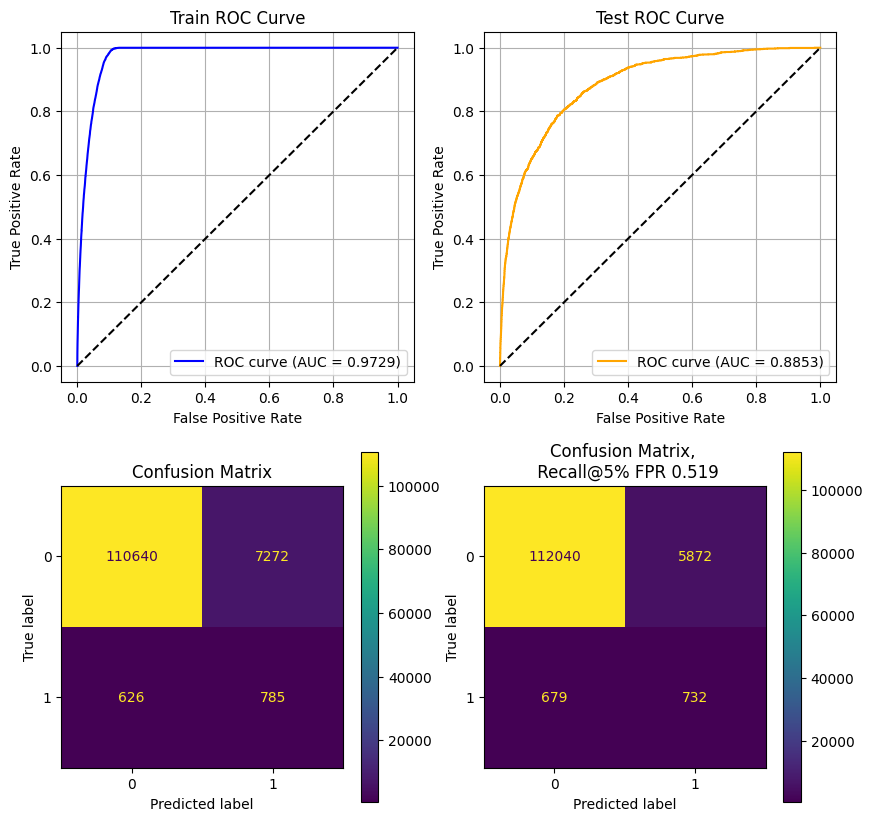

CPU times: total: 16min 54s
Wall time: 3min 21s


In [66]:
%%time

final_forest_params = {
    "class_weight": "balanced_subsample", 
    "random_state": 42,
    "n_jobs": -1,
    "bootstrap": True,
    "criterion": "log_loss",
    "min_samples_leaf": 1e-4,
    "min_impurity_decrease": 5e-5,
    "min_samples_split": 1e-4,
    "max_depth": 40,
    "n_estimators": 350,
}

final_forest = RandomForestClassifier(**final_forest_params)


final_pipe_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_forest),
])

final_pipe_forest.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])


final_forest_fig, final_xgb_axes = model_report(
    final_pipe_forest, 
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

## Optuna XGBoost

In [67]:
def objective_xgb(trial):
    """
    Define the mesh parameters and scoring function
    """
    params = {
        "booster":'gbtree',
        "scale_pos_weight": (len(y_train) - np.sum(y_train)) / np.sum(y_train),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 900, step=10),
        "max_depth": trial.suggest_int("max_depth", 1, 9),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0, step=0.05),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.01, 0.3, log=True),       
        "gamma": trial.suggest_float("gamma", 0, 0.3, step=0.001),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "eval_metric": "logloss"
    }
    
    score = cross_val_score(
        XGBClassifier(**params), X_cv_nf, y_cv_nf, 
        scoring=recall_a5_fpr,
        cv=cv_nf, 
        n_jobs=-1,
        error_score='raise'
    )
    
    return score.mean() - score.std() * 0.75

In [68]:
%%time 
study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgb_v0",  
    storage=storage,  
    load_if_exists=True,  
)

study_xgb.optimize(objective_xgb, n_trials=30)

[I 2025-08-14 18:23:16,951] Using an existing study with name 'xgb_v0' instead of creating a new one.
[I 2025-08-14 18:25:03,515] Trial 30 finished with value: 0.4389417448530055 and parameters: {'learning_rate': 0.13682540893858547, 'n_estimators': 810, 'max_depth': 4, 'subsample': 0.55, 'colsample_bytree': 0.7, 'min_child_weight': 0.016531388360600287, 'gamma': 0.161, 'reg_alpha': 1.8729475271115967e-05, 'reg_lambda': 0.00790456884717351}. Best is trial 22 with value: 0.5413944637591669.
[I 2025-08-14 18:26:10,359] Trial 31 finished with value: 0.5390860678675461 and parameters: {'learning_rate': 0.07405876017262672, 'n_estimators': 640, 'max_depth': 2, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.5, 'min_child_weight': 0.02468538640257673, 'gamma': 0.273, 'reg_alpha': 0.0007792771819456503, 'reg_lambda': 0.32122637201896825}. Best is trial 22 with value: 0.5413944637591669.
[I 2025-08-14 18:27:23,116] Trial 32 finished with value: 0.5361178204783398 and parameters: {'learn

CPU times: total: 19.4 s
Wall time: 35min 41s


Scores are better, than scores of the RandomForest

In [69]:
study_xgb.trials_dataframe().drop(
    ['number', 'datetime_start', 'datetime_complete', 'duration', 'state'], 
    axis=1
).sort_values(by='value', ascending=False).head(6)

,value,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample
54,0.542197,0.50,0.074,0.110935,1,0.017031,770,2.410529e-03,0.036277,0.80
34,0.541957,0.55,0.279,0.115809,1,0.037312,710,3.420100e-05,0.794151,0.85
36,0.541671,0.60,0.290,0.178034,1,0.035822,780,4.269593e-05,0.933219,0.85
35,0.541625,0.60,0.280,0.108616,1,0.034789,650,2.238066e-05,0.993386,0.85
22,0.541394,0.50,0.275,0.046068,2,0.022037,610,2.545059e-07,0.128758,0.75
46,0.541377,0.55,0.064,0.100689,1,0.033050,700,2.146418e-06,0.327339,0.90


I'll take the average parameters that produced the best results (optuna results may have changed when restarting)

In [70]:
%%time

xgb_params_opt = {
    "booster":'gbtree',
    "scale_pos_weight": (len(y_train) - np.sum(y_train)) / np.sum(y_train),
    "n_estimators": 620,
    "max_depth": 2,
    "learning_rate": 0.045,
    "subsample": 0.7,
    "colsample_bytree": 0.5,
    "min_child_weight": 0.03,     
    "gamma": 0.275,
    "reg_alpha": 3e-7,
    "reg_lambda": 3e-7,
    "eval_metric": "logloss"
}


xgb_opt = XGBClassifier(**xgb_params_opt)

xgb_cv_opt = cross_validate(
    xgb_opt,
    X_cv_nf, y_cv_nf, 
    scoring={'roc_auc': 'roc_auc', 
               'Recall@5% FPR': recall_a5_fpr},
    cv=cv_nf, 
    n_jobs=-1,
    return_train_score=True,
    return_estimator=True,
)

CPU times: total: 2.5 s
Wall time: 1min 9s


The model is fitted well: train and test scores are close and high, scores are similar with scores I have recieved at GridSearch and cross-validation. But this model has fewer estimators, works a little faster, so I'll chose theese parameters to the final model

In [71]:
print('Recall_metric:', xgb_cv_opt['test_Recall@5% FPR'].mean() - xgb_cv_opt['test_Recall@5% FPR'].std() * 0.75)
print('roc_auc_metric:', xgb_cv_opt['test_roc_auc'].mean() - xgb_cv_opt['test_roc_auc'].std() * 0.75)
print()

pd.DataFrame(xgb_cv_opt)

Recall_metric: 0.539057988870192
roc_auc_metric: 0.8871454619970912



,fit_time,score_time,estimator,test_roc_auc,train_roc_auc,test_Recall@5% FPR,train_Recall@5% FPR
0,12.297771,0.480108,"XGBClassifier(base_score=None, booster='gbtree...",0.879519,0.902980,0.537563,0.536667
1,24.218466,0.513116,"XGBClassifier(base_score=None, booster='gbtree...",0.886911,0.896541,0.537563,0.547443
2,37.997576,0.557126,"XGBClassifier(base_score=None, booster='gbtree...",0.913043,0.894698,0.581178,0.548768
3,53.054972,0.467113,"XGBClassifier(base_score=None, booster='gbtree...",0.909180,0.899060,0.579201,0.554841
4,65.461778,0.428089,"XGBClassifier(base_score=None, booster='gbtree...",0.895001,0.901548,0.537916,0.561424


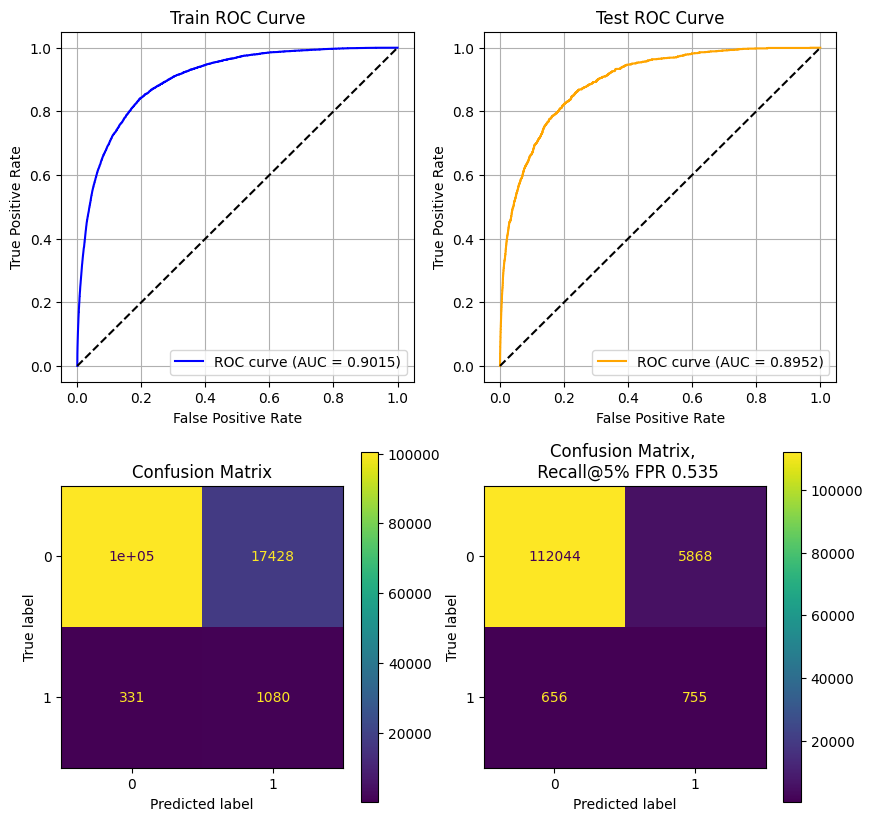

CPU times: total: 1min 46s
Wall time: 42.3 s


In [72]:
%%time

final_xgb_params = {
    "booster":'gbtree',
    "scale_pos_weight": (len(y_train) - np.sum(y_train)) / np.sum(y_train),
    "n_estimators": 620,
    "max_depth": 2,
    "learning_rate": 0.045,
    "subsample": 0.7,
    "colsample_bytree": 0.5,
    "min_child_weight": 0.03,     
    "gamma": 0.275,
    "reg_alpha": 3e-7,
    "reg_lambda": 3e-7,
    "eval_metric": "logloss",
    "seed": 42
}

final_xgb = XGBClassifier(**final_xgb_params)

final_pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_xgb),
])

final_pipe_xgb.fit(X_train[X_train.month<=4], y_train[X_train.month<=4])


final_xgb_fig, final_xgb_axes = model_report(
    final_pipe_xgb, 
    X_train[X_train.month<=4], y_train[X_train.month<=4], 
    X_train[X_train.month==5], y_train[X_train.month==5],
)

plt.show()

## Conclusion

Hyperparameters were selected for the RandomForest and XGBoost models. Recall@5% FPR of both models is above 0.5. 

The RandomForest model shows slightly worse results than XGBoost. The auc_roc score of the RandomForest model on the train is close to 1, and on the test it is significantly less (about 0.89). To combat overfitting, the model was simplified, but this led to a decrease in both the scores on the train and on the test. 

The XGBoost model trained well - the scores on the train and on the test is approximately the same.

# Statistical test for model selection

The scores of the XGBoost model are better than the scores of the RandomForest model. But it is incorrect to compare only the two scores - perhaps in fact the models predict approximately the same.To test this, a statistical test will be performed to determine whether the mean predictions of the two models are equal.

## Final models

In [73]:
%%time
# training on the whole training sample

final_pipe_xgb.fit(X_train, y_train)
final_pipe_forest.fit(X_train, y_train)
print('fitted')

fitted
CPU times: total: 21min 17s
Wall time: 4min 11s


In [74]:
# preprocess test data (models have the same preprocessing)
X_test_transformed = final_pipe_xgb['preprocessor'].transform(X_test)
X_test_transformed.index = y_test.index

## Determining the size of bootstrap samples and the number of experiments

To select a model, a paired statistical test for equality of the mean samples of the Recall@5% FPR metric values will be conducted.

The target metric is measured on a sample, not on a single object. The test sample consists of 200 thousand independent applications. Conducting measurements on a large number of bootstrap subsamples of 200 thousand requires a lot of time. To optimize the time resources spent on conducting the test, bootstrap subsamples of a smaller size will be used.

Input data for the test:

- $H_0$: The average difference in metrics between the two models is zero, meaning the models do not differ in metrics;
- $H_1$: The average difference in metrics between the two models is not zero, the models are different;
- minimum detectable effect Δ = 0.005;
- significance level &alpha; = 0.05;
- power &beta; = 0.8.

It is possible to carry out 1000 tests, but I should to determine the size of a bootsrap sample *m*. To determine this, I will conduct a pilot test: on N_0 = 400 iterations for samples of size *m* = (1000, 2000, 5000, 8000, 12000), I will determine the standard deviation of the differences in metrics between models on these m. I will determine the sample size at which the reduction in variance is satisfactory.

In [75]:
delta = 0.005 # MDE
alpha = 0.05
beta = 0.8 # power

N = 1000 # number of tests (final sample size)

N_0 = 400 
ms = [1000, 2000, 5000, 8000, 12000] # bootstrapped sample sizes

In [76]:
samples = dict() # dictionary with 400 arrays of indexes for every size of bootstrapped sample

for m in ms:
    idx = []
    for  _ in range(N_0):
        idx.append(np.random.choice(X_test_transformed.index, size=m, replace=True))
    samples[m] = idx

In [77]:
%%time

scorer_forest = check_scoring(final_pipe_forest['model'], scoring=recall_a5_fpr)
scorer_xgb = check_scoring(final_pipe_xgb['model'], scoring=recall_a5_fpr)

scores_m = dict() # dictionary with 400 tuples of scores for every size of bootstrapped sample

for m in ms:
    scores_xgb = []
    scores_forest = []
    for idx in samples[m]:
        scores_xgb.append(scorer_xgb(final_pipe_xgb['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
        scores_forest.append(scorer_forest(final_pipe_forest['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
    
    scores_m[m] = (np.array(scores_xgb), np.array(scores_forest))

CPU times: total: 20min
Wall time: 3min 41s


In [78]:
results = dict() # dictionary with standard deviations for every size of bootstrapped sample

for m in ms:
    d_0 = scores_m[m][0] - scores_m[m][1] # array with difference of scores
    
    results[m] = np.std(d_0, ddof=1)

The standard deviation decreases as the size of the bootstrapped samples increases

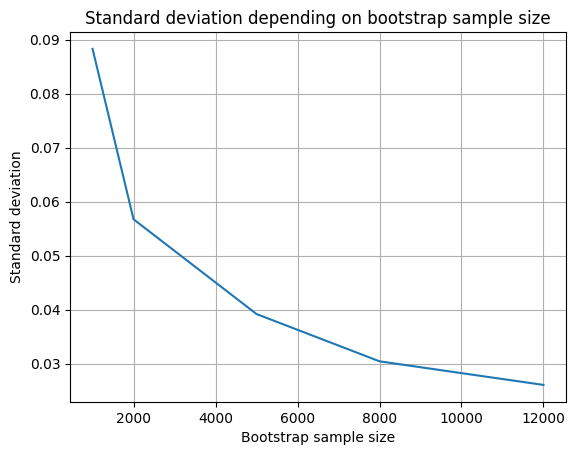

In [79]:
st_figure = plt.figure()
sns.lineplot(x=list(results.keys()), y=list(results.values()))
plt.title("Standard deviation depending on bootstrap sample size")
plt.xlabel("Bootstrap sample size")
plt.ylabel("Standard deviation")
plt.grid(True)
plt.show()

Because 
$$ s * \sqrt{m} \approx constant$$
I can use the ratio to predict the variance, depending on *m* - $\sigma^2(m)$

Formula of Minimum Detectable Effect (MDE):
$$
effect = (t_{(1-\frac{\alpha}{2})}+ t_\beta)s\sqrt{\frac{1}{N}}
$$
so 
$$s(m) = \frac{\sqrt{N} * effect }{ (t_{(1-\frac{\alpha}{2})}+ t_\beta)}
$$
and 
$$
m \approx \frac {m_i * s(m_i)^2}{s(m)^2}  = \frac {m_i * s(m_i)^2}{\left(\frac{\sqrt{N} * effect }{(t_{(1-\frac{\alpha}{2})}+ t_\beta)}\right)^2} = m_i * s(m_i)^2 * \frac {(t_{(1-\frac{\alpha}{2})}+ t_\beta)^2}{N* (effect) ^2 }
$$

In [80]:
max_constant = 0
for m in ms:
    val = results[m]  * np.sqrt(m)
    print(f"C({m}) = {val:.2f}")
    if val > max_constant:
        max_constant = val
del val

C(1000) = 2.79
C(2000) = 2.54
C(5000) = 2.77
C(8000) = 2.72
C(12000) = 2.86


In [81]:
final_m = max_constant**2 * (t(N-1).ppf(q=1-alpha/2) + t(N-1).ppf(q=beta))**2 / delta**2 / N
print(f"Calculated m: {int(final_m)}")

inc_coef = 1.3  # increase the size

final_m = int(np.ceil(final_m * inc_coef / 100) * 100)
print(f"Accepted m: {int(final_m)}")

Calculated m: 2565
Accepted m: 3400


## t-test

Creating *N* bootstrapped samples of size *m* and getting the scores of the models

In [82]:
%%time

scorer_forest = check_scoring(final_pipe_forest['model'], scoring=recall_a5_fpr)
scorer_xgb = check_scoring(final_pipe_xgb['model'], scoring=recall_a5_fpr)

final_scores_xgb = []
final_scores_forest = []


for _ in range(N):
    idx = np.random.choice(X_test_transformed.index, size=final_m, replace=True)

    final_scores_xgb.append(scorer_xgb(final_pipe_xgb['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
    final_scores_forest.append(scorer_forest(final_pipe_forest['model'],  X_test_transformed.loc[idx], y_test.loc[idx]))
    
final_scores_xgb = np.array(final_scores_xgb)
final_scores_forest = np.array(final_scores_forest)

CPU times: total: 9min 3s
Wall time: 1min 34s


It is evident that the distribution of the XGBoost scores is shifted to the right.

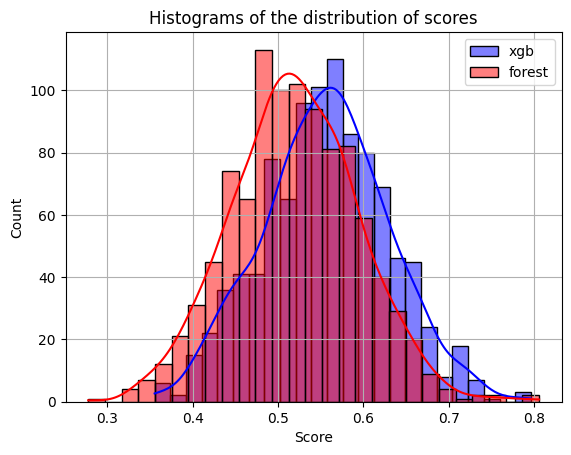

In [83]:
distibutions_plot = plt.figure()
sns.histplot(final_scores_xgb, color='blue', label='xgb', kde=True, alpha=0.5)
sns.histplot(final_scores_forest, color='red', label='forest', kde=True, alpha=0.5)
plt.title('Histograms of the distribution of scores')
plt.legend()
plt.xlabel("Score")
plt.grid(True)
plt.show()

In [84]:
ttest_rel(final_scores_xgb, final_scores_forest, alternative='two-sided')

TtestResult(statistic=25.433692607922612, pvalue=1.9824668062166087e-110, df=999)

The p-value is less than the significance level (0.05), the null hypothesis can be rejected

# Probability calibration

Most likely, the probabilities predicted by the model will not coincide with the real distribution of classes. To check this, I will build a calibration curve

The predicted probabilities are indeed far from the real distribution. It is necessary to calibrate the probabilities - to adjust the predictions to the real distribution of classes (to bring the probability curve closer to the diagonal)

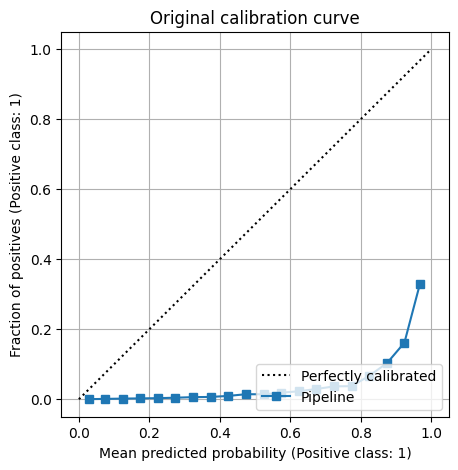

In [85]:
CalibrationDisplay.from_estimator(final_pipe_xgb, X_test, y_test, n_bins=20).figure_.set_size_inches(5, 5)
plt.title('Original calibration curve')
plt.grid()
plt.show()

I will use Platt's calibration, which is based on the sigmoid function. The model will return calibrated probability estimates.

In [86]:
%%time

platts_calibration = CalibratedClassifierCV(
    final_pipe_xgb,
    method='sigmoid',
    ensemble=False,
    cv=5,
    n_jobs = -1
).fit(X_train, y_train)

CPU times: total: 1min 47s
Wall time: 2min 1s


The maximum predicted probability now does not exceed 0.2 (previously it was almost 1) - this is logical, given the distribution of the target class (only 1%), so even if the model sees a fraudulent application, it cannot be 99% sure due to their rarity

Starting with a probability of ~0.12, the distribution of predicted probabilities begins to diverge from the distribution of the target class. However, if you look at the distribution of predicted probabilities, you can see that this is due to the fact that there are very few such objects

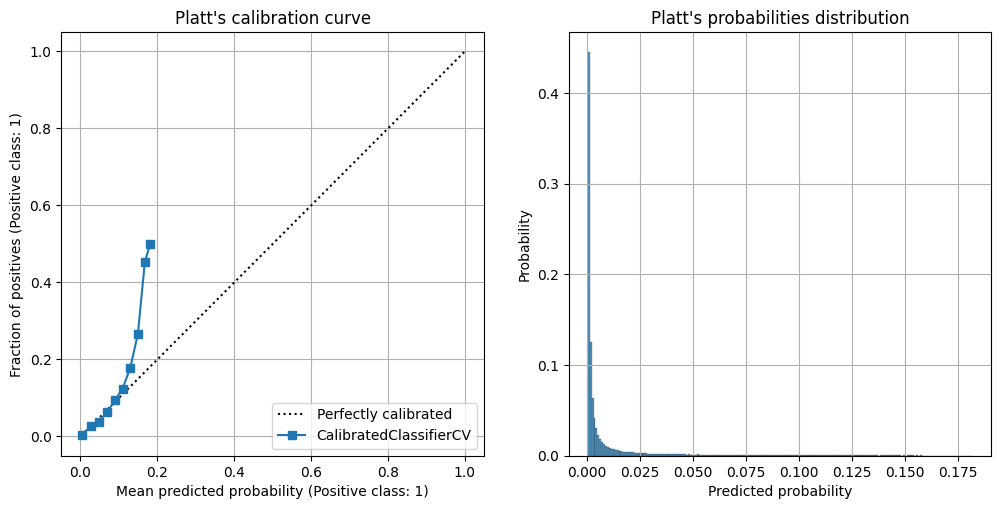

CPU times: total: 8.69 s
Wall time: 7.36 s


In [87]:
%%time

fig_platt, axes_platt = plt.subplots(1, 2, figsize=(12, 5.5))

CalibrationDisplay.from_estimator(platts_calibration, X_test, y_test, n_bins=50, ax=axes_platt[0])
axes_platt[0].grid()
axes_platt[0].set_title("Platt's calibration curve")

platts_p = platts_calibration.predict_proba(X_test)[:, 1]

sns.histplot(platts_p, bins=200, ax=axes_platt[1], stat='probability')
axes_platt[1].set_xlabel('Predicted probability')
axes_platt[1].grid()
axes_platt[1].set_title("Platt's probabilities distribution")

plt.show()

I will also try using the isotonic method. This method is not based on the sigmoid function, but on an arbitrary monotonic function. On large datasets, it can produce better results than Platt's calibration.

In [88]:
%%time

iso_calibration = CalibratedClassifierCV(
    final_pipe_xgb,
    method='isotonic',
    ensemble=False,
    cv=5,
    n_jobs = -1
).fit(X_train, y_train)

CPU times: total: 1min 48s
Wall time: 2min


The maximum predicted probability is now close to 1 again, but for probabilities greater than 0.2 the curve is unstable.

The distribution of predicted probabilities is similar to the previous one, but not smoothed.

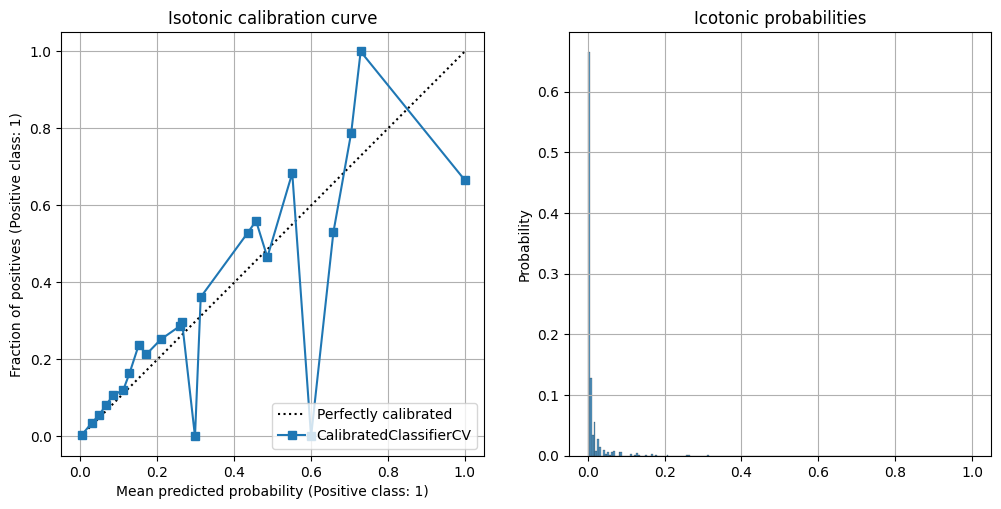

CPU times: total: 8.58 s
Wall time: 7.36 s


In [89]:
%%time

fig_iso, axes_iso = plt.subplots(1, 2, figsize=(12, 5.5))

CalibrationDisplay.from_estimator(iso_calibration, X_test, y_test, n_bins=50, ax=axes_iso[0])
axes_iso[0].grid()
axes_iso[0].set_title("Isotonic calibration curve")

iso_p = iso_calibration.predict_proba(X_test)[:, 1]

sns.histplot(iso_p, bins=200, ax=axes_iso[1], stat='probability')
axes_platt[1].set_xlabel('Predicted probability')
axes_iso[1].grid()
axes_iso[1].set_title("Icotonic probabilities")

plt.show()

I will compare the metric values for the two methods

In [90]:
%%time
def expected_calibration_error(y_true, y_prob, n_bins=20):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (y_prob > bins[i]) & (y_prob <= bins[i+1])
        if np.sum(mask) == 0:
            continue
        bin_prob = np.mean(y_prob[mask])
        bin_true = np.mean(y_true[mask])
        ece += (np.sum(mask) / len(y_true)) * abs(bin_prob - bin_true)
    return ece


p = platts_p
scorer_xgb_platt = check_scoring(platts_calibration , scoring=recall_a5_fpr)
print("sigmoid")
print("=======")
print("Brier:", np.round(brier_score_loss(y_test, p), 4))
print("LogLoss:", np.round(log_loss(y_test, p), 4))
print("ECE(50):", np.round(expected_calibration_error(y_test, p, n_bins=50), 4))
print("AUC:", np.round(roc_auc_score(y_test, p), 4))
print("Recall@5% FPR", np.round(scorer_xgb_platt(platts_calibration, X_test, y_test), 4))

print()

p = iso_p
scorer_xgb_iso = check_scoring(iso_calibration , scoring=recall_a5_fpr)
print("isotonic")
print("========")
print("Brier:", np.round(brier_score_loss(y_test, p), 4))
print("LogLoss:", np.round(log_loss(y_test, p), 4))
print("ECE(50):", np.round(expected_calibration_error(y_test, p, n_bins=50), 4))
print("AUC:", np.round(roc_auc_score(y_test, p), 4))
print("Recall@5% FPR", np.round(scorer_xgb_iso(iso_calibration, X_test, y_test), 4))

print()

sigmoid
Brier: 0.0127
LogLoss: 0.0552
ECE(50): 0.0033
AUC: 0.8934
Recall@5% FPR 0.5552

isotonic
Brier: 0.0124
LogLoss: 0.0547
ECE(50): 0.0024
AUC: 0.8932
Recall@5% FPR 0.5532

CPU times: total: 8 s
Wall time: 7.14 s


The metrics for the two calibration methods are almost identical. The isotonic method gives slightly better results for Brier loss, log loss, and expected calibration error (ECE(50)), but the difference is so small that it may be due to noise.

I will choose Platt's calibration because it showed more stable results and is likely to produce more reliable performance in production.

# Final wrapper for the model

After applying Platt's calibration, which returns probabilities in the range (0, 0.2), the predict method stopped working correctly (since all probabilities are below 0.5).

I will write a wrapper for the model that will redefine the classification threshold — so that the model classifies an instance as positive only if the threshold corresponds to approximately 5% FPR.

Additionally, during EDA, a constant feature device_fraud_count was found to be equal to 0 for all instances and was not used in training. I will add it to the wrapper in such a way that for instances where device_fraud_count is greater than 0, the model will return the maximum probability observed during the fit stage (thus assigning the instance to the positive class).

In [91]:
class ClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, target_fpr=0.05):
        self.base_model = model
        self.target_fpr = target_fpr
        
    
    def fit(self, X, y):
        
        self.cv_thresholds = []
        self.max_threshold = 0

        for train_idx, val_idx in TimeSeriesMonthSplit().split(X, y):
            X_train, y_train = X.loc[train_idx], y.loc[train_idx]
            X_val, y_val = X.loc[val_idx], y.loc[val_idx]

            model = clone(self.base_model)
            model.fit(X_train, y_train)

            y_score = model.predict_proba(X_val)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_val, y_score)
            self.cv_thresholds.append(thresholds[np.where(fpr <= self.target_fpr)[0].max()])
            self.max_threshold = np.max([self.max_threshold, np.sort(thresholds)[-2]]) # the last threshold = inf

        self.threshold_fpr = np.median(self.cv_thresholds)

        self.model = clone(self.base_model)
        self.model.fit(X, y)
      
        self._is_fitted = True
    
        return self

    def predict(self, X):
        check_is_fitted(self)
        # Shortcut: if device_fraud_count > 0,return 1
        probas = self.predict_proba(X)[:,1]
        return (probas>=self.threshold_fpr).astype(int)

    def predict_proba(self, X):
        check_is_fitted(self)
        probas = self.model.predict_proba(X)
        if 'device_fraud_count' in X.columns:
            fraud_idx = X['device_fraud_count'] > 0
            probas[fraud_idx, 0] = 1 - self.max_threshold # class 0
            probas[fraud_idx, 1] = self.max_threshold  # class 1
        return probas

    def __sklearn_is_fitted__(self):
        """
        Check fitted status and return a Boolean value.
        """
        return hasattr(self, "_is_fitted") and self._is_fitted

    @property
    def classes_(self):
        check_is_fitted(self)
        return self.model.classes_

In [92]:
%%time
wrapped_classifier = ClassifierWrapper(platts_calibration).fit(X_train, y_train)

CPU times: total: 6min 27s
Wall time: 7min 11s


In [93]:
probas = wrapped_classifier.predict_proba(X_test)[:, 1]
preds = wrapped_classifier.predict(X_test)

In [94]:
(probas>=wrapped_classifier.threshold_fpr).astype(int) == preds

array([ True,  True,  True, ...,  True,  True,  True])

FPR on the test sample is slightly higher than 5%

In [98]:
print(f"Current threshold: {wrapped_classifier.threshold_fpr:.3f}")

for t in np.sort(wrapped_classifier.cv_thresholds):
    print(f"{t:.3f}: {(np.sum((probas>=t).astype(int) - (probas>=t).astype(int) * y_test) / len(X_test)):.4f}")

Current threshold: 0.059
0.039: 0.0816
0.048: 0.0660
0.059: 0.0528
0.062: 0.0498
0.077: 0.0366


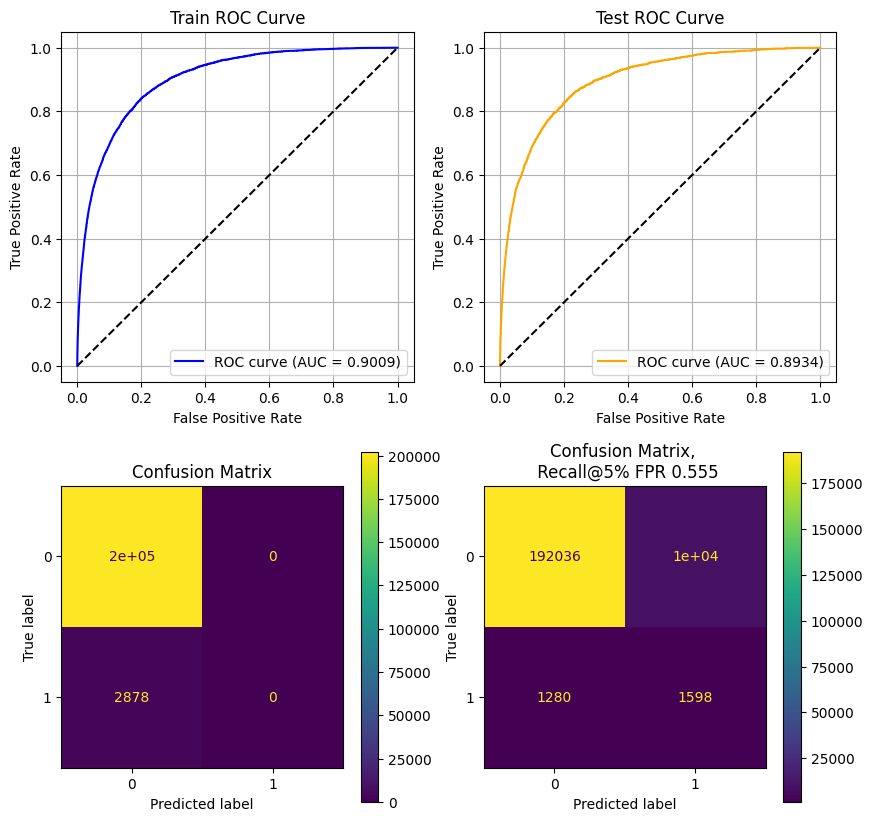

In [99]:
model_report(
    wrapped_classifier,
    X_train, y_train, 
    X_test, y_test,
)

plt.show()

# Conclusion

In this notebook, a classification model was trained, and hyperparameter tuning was performed using GridSearchCV and Optuna.
Two models showing the best cross-validation results were selected: RandomForest and XGBoost.

Next, a paired statistical test was conducted to check the equality of the mean values of the Recall@5% FPR metric for the two models. Based on the test results (p-value below the 0.05 significance level), the null hypothesis — that the average difference in metrics between the two models is zero — was rejected.

After that, probability calibration for the XGBoost model was performed using Platt’s method. The predicted probabilities of belonging to the positive class did not exceed 0.2.

Finally, a model wrapper was implemented, overriding the predict method so that the FPR on the test set is approximately 5%. The wrapper also returns the maximum probability of belonging to the positive class for instances where the device_fraud_count feature is greater than 0 (in the training set this feature was constant and was not used in training).